In [1]:
import astropy.units as u
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from sklearn.ensemble import RandomForestClassifier
from astropy.table import Table
import seaborn as sns
import os
from astropy.stats import sigma_clip
plt.rcParams['text.usetex'] = False

# EXPERIENCIA 4

# PARTE 1

## OPENING TABLES

In this part we:
- Drop NaNs
- Select the columns to use
- Remove outliers

In [2]:
all_star = fits.open('galah_dr4_allstar_240705.fits')
dyn = fits.open('galah_dr4_vac_dynamics_240705.fits')
phot = fits.open('galah_dr4_vac_wise_tmass_gaiadr3_240705.fits')
abun = fits.open('galah_dr4_vac_3dnlte_a_li_240705.fits')

In [3]:
all_star.info()

Filename: galah_dr4_allstar_240705.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  Joined        1 BinTableHDU    801   917588R x 184C   [K, 17A, K, 17A, J, 7A, E, D, D, J, J, J, J, E, E, E, E, E, K, 16A, 16A, E, L, E, E, E, E, E, E, D, E, E, E, E, E, E, J, E, E, E, E, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, J, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, D, D, E, D, E, E, E, E, E, E, E, E, E, K]   


In [4]:
as_hdu = all_star[1].header

The data comes as FITS_rec objects. You can access the column names by using the .columns attribute.

In [5]:
allstar_data = all_star[1].data
dyn_data = dyn[1].data
phot_data = phot[1].data
abun_data = abun[1].data

In [6]:
as_cols = ['sobject_id', 'tmass_id', 'source_id',
          'teff', 'logg', 'fe_h', 'vmic', 'vsini',
          'mass', 'age', 'lbol', 'li_fe', 'c_fe', 
           'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe', 
           'mg_fe', 'si_fe', 'ca_fe', 'ti_fe', 'sc_fe', 
           'c_fe', 'cr_fe', 'mn_fe','co_fe', 'ni_fe', 
           'cu_fe', 'zn_fe', 'y_fe',
           'snr_px_ccd3','flag_sp', 'flag_n_fe', 'flag_o_fe', 'flag_na_fe', 
           'flag_teff', 'flag_logg', 'flag_fe_h', 'flag_vmic', 'flag_vsini',
          'flag_mass', 'flag_age', 'flag_al_fe', 'flag_k_fe', 
           'flag_mg_fe', 'flag_si_fe', 'flag_ca_fe', 'flag_ti_fe', 'flag_sc_fe', 
           'flag_c_fe', 'flag_cr_fe', 'flag_mn_fe','flag_co_fe', 'flag_ni_fe', 
           'flag_cu_fe', 'flag_zn_fe', 'flag_rb_fe', 'flag_sr_fe', 'flag_y_fe']

dyn_cols = ['sobject_id', 'tmass_id', 'source_id', 'U_UVW', 'V_UVW', 'W_UVW']

Use isna().sum() to see percentage of elements that have NaNs in the columns.

In [7]:
as_table = pd.DataFrame(allstar_data).filter(items=as_cols)#.dropna(axis=0)
dyn_table = pd.DataFrame(dyn_data).filter(items=dyn_cols)#.dropna(axis=0)
phot_table = pd.DataFrame(phot_data)
abun_table = pd.DataFrame(abun_data).filter(items=['sobject_id', 'ALi', 'flag_ALi'])

In [8]:
abun_table.columns

Index(['sobject_id', 'ALi', 'flag_ALi'], dtype='object')

In [9]:
for col in as_table.columns:
    if 'fe' in col and 'flag' not in col:
        nan = as_table[col].isna().sum()
        print(f"{col} : {(nan/len(as_table[col])) * 100}")

fe_h : 1.187896964650802
c_fe : 1.37883232997816
n_fe : 24.849060798528317
o_fe : 4.723470664394042
na_fe : 2.5808968731064486
al_fe : 7.441030179121784
k_fe : 6.24724822033418
mg_fe : 2.1315666726243148
si_fe : 3.463645993626769
ca_fe : 1.9031417150180692
ti_fe : 1.6143410768231492
sc_fe : 2.0329385301464273
cr_fe : 1.5575617815402991
mn_fe : 1.906629118950989
co_fe : 8.647018051674609
ni_fe : 1.716892548725572
cu_fe : 9.515163668225826
zn_fe : 4.924977222893063
y_fe : 1.7139500516571708


## Combinar tabla de abundancia con tabla de dinámica.

In [10]:
main_table1 = pd.merge(as_table, dyn_table, on='sobject_id')
main_table = pd.merge(main_table1, abun_table, on='sobject_id')

In [11]:
len(main_table)

892224

## Escoger aquellos datos con:
- flags == 0
- Snr_px_ccd3 > 30

In [12]:
mask_snr = main_table['snr_px_ccd3'] > 30
clean_table = main_table[mask_snr]

In [13]:
len(clean_table)

803135

## Ver rápidamente datos.

Text(0, 0.5, '$\\sqrt{V_{LSR}^2 + W_{LSR}^2}$ (km/s)')

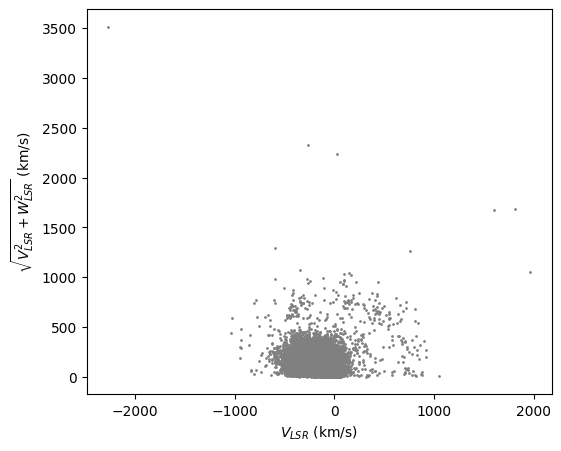

In [14]:
fig, ax = plt.subplots(figsize=[6,5])

ax.scatter(clean_table['V_UVW'], np.sqrt(clean_table['U_UVW']**2 + clean_table['W_UVW']**2),
          s=1, c='gray')
ax.set_xlabel('$V_{LSR}$ (km/s)')
ax.set_ylabel('$\sqrt{V_{LSR}^2 + W_{LSR}^2}$ (km/s)')

## Eliminating outliers.

### Inspecting distribution.

In [15]:
for col in clean_table.columns:
    if 'flag' not in col and 'id' not in col:
        fig1 = plt.figure(figsize=(5,4))
    
        x = clean_table[col]
        # x = x[np.isfinite(x)]
        # x = np.log10(x)
        Bins = np.linspace(min(x),max(x),20)
        plt.hist(x,bins=Bins,log=False, color='black', histtype='step')
        plt.xlabel(col)
        plt.ylabel('N')
    
        path_histo = os.path.join('plots', 'histo', f'{col}')
        plt.savefig(path_histo)
        plt.close()

## Checking sigma-clipping.

803135 803135


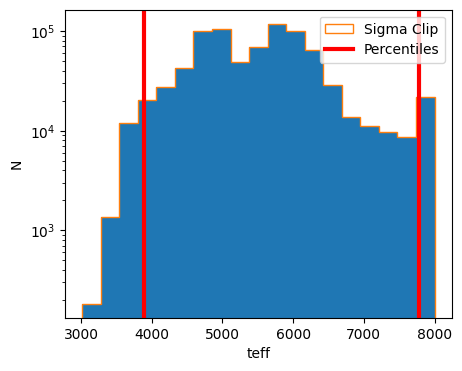

803135 803135


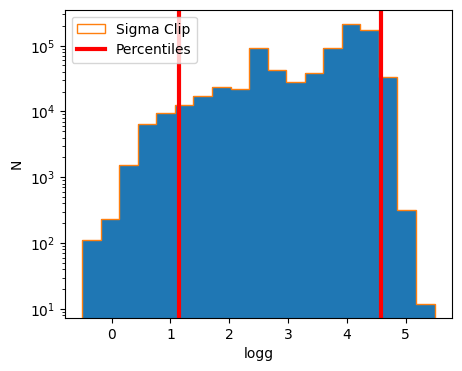

803135 803135


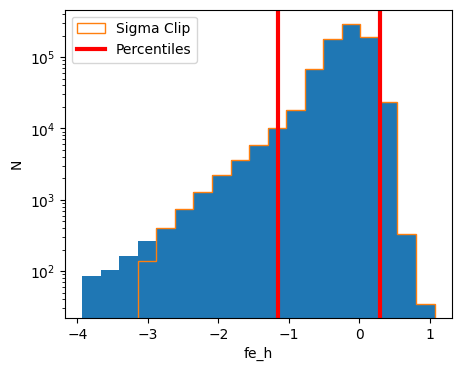

803135 803135


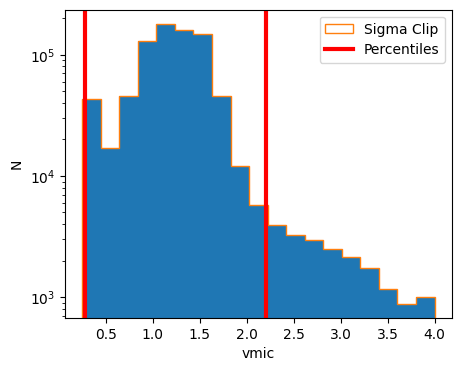

803135 803135


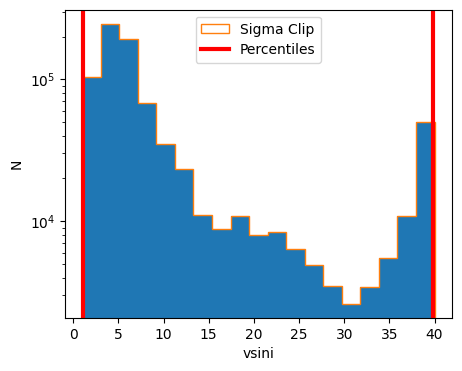

803135 803135


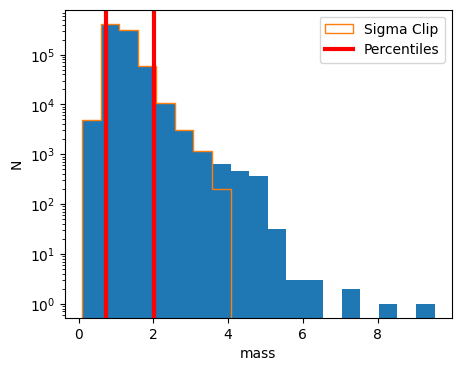

803135 803135


In [ ]:
SacarOutliers = True
for col in clean_table.columns:
    if 'flag' not in col and 'id' not in col:
        fig1 = plt.figure(figsize=(5,4))
    
        x = clean_table[col]
        # x = x[np.isfinite(x)]
        # x = np.log10(x)
        Bins = np.linspace(min(x),max(x),20)
        plt.hist(x,bins=Bins,log=False)
        plt.xlabel(col)
        plt.ylabel('N')
    
        filtered_data = sigma_clip(x, sigma=8,masked=True)
        print(len(filtered_data),len(x))
        if SacarOutliers:
            data = clean_table[~filtered_data.mask]
            
        plt.hist(filtered_data.compressed(),bins=Bins,log=True,label='Sigma Clip', histtype='step')
        plt.axvline(np.percentile(x,[2.5])[0],color='red',lw=3,label='Percentiles')
        plt.axvline(np.percentile(x,[97.5])[0],color='red',lw=3)
        plt.xlabel(col)
        plt.ylabel('N')
        plt.legend(loc=0)

        path_clip = os.path.join('plots', 'sigma_clipped_histo', f'{col}')
        plt.savefig(path_clip)
        plt.show()
        plt.clf()
        plt.close()

In [ ]:
t = data.drop(columns=['sobject_id', 'tmass_id_x', 'tmass_id_y'])
corrs = t.corr()
corrs.style.background_gradient(cmap='coolwarm',vmin=-1,vmax=1)

Considerar ciertas temperaturas; paper hayden?

In [ ]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor # Import Decision Tree Classifier
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image  
import pydotplus
from sklearn import tree
from astropy.table import Table
# import graphviz
from joblib import parallel_backend
from sklearn import linear_model
from sklearn import svm

# SEPARATING STARS BY MEMBERSHIP TO MW STRUCTURE

## TOOMRE DIAGRAM

In [ ]:
def v_tot(u, v, w):
    return np.sqrt(u ** 2 + v ** 2 + w ** 2)

In [ ]:
data_toomre = data.copy()

In [ ]:
data_toomre['magnitude'] = np.sqrt(data_toomre['U_UVW']**2 + data_toomre['V_UVW']**2 + data_toomre['W_UVW']**2)

data_toomre['flag_thin'] = 0
data_toomre['flag_thick'] = 0
data_toomre['flag_halo'] = 0

# Assign the flag based on the condition
data_toomre.loc[data_toomre['magnitude'] < 50, 'flag_thin'] = 1
data_toomre.loc[(data_toomre['magnitude'] > 50) & (data_toomre['magnitude'] < 180), 'flag_thick'] = 1
data_toomre.loc[data_toomre['magnitude'] > 180, 'flag_halo'] = 1

In [ ]:
data_toomre

In [ ]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=[5,4], dpi=300)

#ax.scatter(data_toomre['V_UVW'], np.sqrt(data_toomre['U_UVW']**2 + data_toomre['W_UVW']**2),
          #s=1, c='gray')

ax.scatter(data_toomre['V_UVW'][data_toomre['flag_thin'] == 1], np.sqrt(data_toomre['U_UVW'][data_toomre['flag_thin'] == 1]**2 + data_toomre['W_UVW'][data_toomre['flag_thin'] == 1]**2),
          marker='v', c='crimson', s=0.2, label='Thin')
ax.scatter(data_toomre['V_UVW'][data_toomre['flag_thick'] ==1], np.sqrt(data_toomre['U_UVW'][data_toomre['flag_thick'] ==1]**2 + data_toomre['W_UVW'][data_toomre['flag_thick'] ==1]**2),
          marker='s', c='mediumvioletred', s=0.2, label='Thick')
ax.scatter(data_toomre['V_UVW'][data_toomre['flag_halo'] == 1], np.sqrt(data_toomre['U_UVW'][data_toomre['flag_halo'] == 1]**2 + data_toomre['W_UVW'][data_toomre['flag_halo'] == 1]**2),
          marker='d', c='plum', s=0.2, label='Halo')

ax.set_xlabel('$V_{LSR}$ (km/s)')
ax.set_ylabel('$\sqrt{U_{LSR}^2 + W_{LSR}^2}$ (km/s)')
circle_1 = Circle((0,0), radius=50, linestyle='--', fill=None, color='limegreen', lw=1)
circle_2 = Circle((0,0), radius=70, linestyle='--', fill=None, color='limegreen', lw=1)
circle_3 = Circle((0,0), radius=180, linestyle='--', fill=None, color='limegreen', lw=1)
ax.add_patch(circle_1)
ax.add_patch(circle_2)
ax.add_patch(circle_3)
ax.set_ylim(0, 400)
ax.set_xlim(-500, 100)
#sm = plt.cm.ScalarMappable(cmap='magma')
#sm.set_array([])  # Required for ScalarMappable to work
#cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.04)
#cbar.set_label('Percentage of stars', fontsize=14)
plt.legend(fontsize=10)
fig.tight_layout()
plt.savefig('toomre.png')
plt.show()

In [ ]:
def alpha_fe(si, ti, mg, fe_h):
    n_fe = (10 ** 7.50) * 10 ** fe_h
    n_si = n_fe * 10 ** si
    n_ti = n_fe * 10 ** ti
    n_mg = n_fe + 10 ** mg

    n_alfa = n_si + n_ti + n_mg
    
    alfa_fe = np.log10(n_alfa/ n_fe) - 0.348
    return alfa_fe

alfa_fe = alpha_fe(data_toomre['si_fe'], data_toomre['ti_fe'], data_toomre['mg_fe'], data_toomre['fe_h'])


In [ ]:
fig, ax = plt.subplots(figsize=[4, 3])

ax.scatter(data_toomre['fe_h'], alfa_fe, s=0.4, alpha=0.1, c='black')
ax.set_xlabel('[Fe/H]', fontsize=13)
ax.set_ylabel('[alpha/Fe]', fontsize=13)
ax.set_xlim(-2.5, 1)
ax.set_ylim(0, 0.8)
ax.tick_params(labelsize=13)
fig.tight_layout()
ax.axhline(0.17, ls='dotted', c='crimson')
ax.axhline(0.4, ls='dotted', c='crimson')
plt.savefig('abundance_sep')
plt.show()

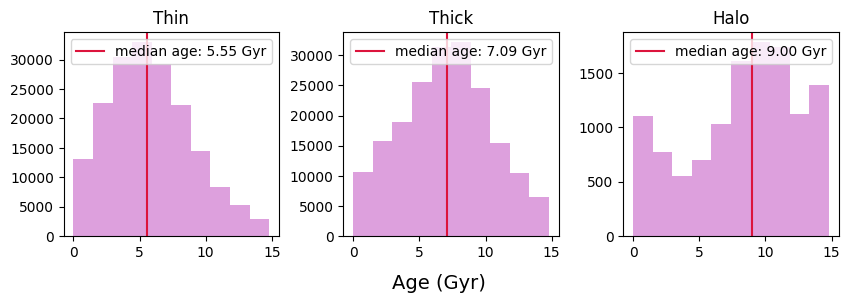

In [24]:
fig, ax = plt.subplots(figsize=[10,3], ncols=3)
fig.supxlabel('Age (Gyr)', fontsize=14)
ax[0].hist(data_toomre[data_toomre['flag_thin'] == 1]['age'], color='plum')
ax[0].set_title('Thin')
ax[0].axvline(np.nanmedian(data_toomre[data_toomre['flag_thin'] == 1]['age']), c='crimson', label=f"median age: {np.nanmedian(data_toomre[data_toomre['flag_thin'] == 1]['age']):.2f} Gyr")
ax[0].legend()

ax[1].hist(data_toomre[data_toomre['flag_thick'] == 1]['age'], color='plum')
ax[1].set_title('Thick')
ax[1].axvline(np.nanmedian(data_toomre[data_toomre['flag_thick'] == 1]['age']), c='crimson', label=f"median age: {np.nanmedian(data_toomre[data_toomre['flag_thick'] == 1]['age']):.2f} Gyr")
ax[1].legend()

ax[2].hist(data_toomre[data_toomre['flag_halo'] == 1]['age'], color='plum')
ax[2].set_title('Halo')
ax[2].axvline(np.nanmedian(data_toomre[data_toomre['flag_halo'] == 1]['age']), c='crimson', label=f"median age: {np.nanmedian(data_toomre[data_toomre['flag_halo'] == 1]['age']):.2f} Gyr")
ax[2].legend()

plt.subplots_adjust(bottom=0.2)
plt.subplots_adjust(wspace=0.3)
plt.savefig('age_dist.png')
plt.show()

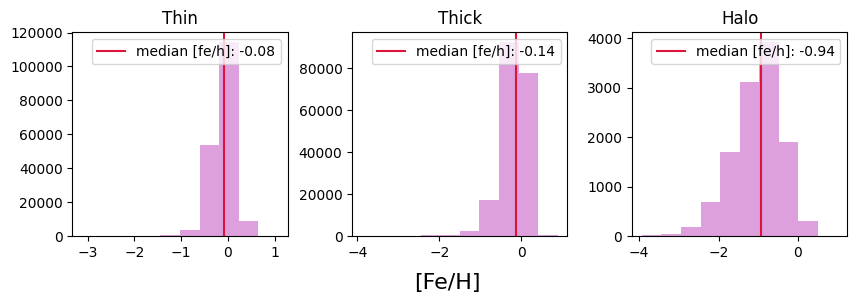

In [25]:
fig, ax = plt.subplots(figsize=[10,3], ncols=3)
fig.supxlabel('[Fe/H]', fontsize=16)
ax[0].hist(data_toomre[data_toomre['flag_thin'] == 1]['fe_h'], color='plum')
ax[0].set_title('Thin')
ax[0].axvline(np.nanmedian(data_toomre[data_toomre['flag_thin'] == 1]['fe_h']), c='crimson', label=f"median [fe/h]: {np.nanmedian(data_toomre[data_toomre['flag_thin'] == 1]['fe_h']):.2f}")
ax[0].legend()

ax[1].hist(data_toomre[data_toomre['flag_thick'] == 1]['fe_h'], color='plum')
ax[1].set_title('Thick')
ax[1].axvline(np.nanmedian(data_toomre[data_toomre['flag_thick'] == 1]['fe_h']), c='crimson', label=f"median [fe/h]: {np.nanmedian(data_toomre[data_toomre['flag_thick'] == 1]['fe_h']):.2f}")
ax[1].legend()

ax[2].hist(data_toomre[data_toomre['flag_halo'] == 1]['fe_h'], color='plum')
ax[2].set_title('Halo')
ax[2].axvline(np.nanmedian(data_toomre[data_toomre['flag_halo'] == 1]['fe_h']), c='crimson', label=f"median [fe/h]: {np.nanmedian(data_toomre[data_toomre['flag_halo'] == 1]['fe_h']):.2f}")
ax[2].legend()

plt.subplots_adjust(bottom=0.2)
plt.subplots_adjust(wspace=0.3)
plt.savefig('feh_dist.png')
plt.show()

## PROBABILITIES

In [26]:
def prob(U, V, W, V_lag, sigma_U, sigma_V, sigma_W):
    # From Kordopatis et al. 2018
    # The kinematic approach of Soubiran & Girard
    #(2005); Bensby & Feltzing (2006); Ruchti et al. (2010)
    # Bensby et al. 2003 (explica todo en detalle)
    k = 1 / (np.sqrt((2 * np.pi) ** 3) * sigma_U * sigma_V * sigma_W)
    fracs = -U ** 2 / (2 * sigma_U ** 2) - (V - V_lag) ** 2 / (2 * sigma_V ** 2) - W ** 2 / (2 * sigma_W ** 2)
    p = k * np.exp(fracs)

    return p

In [27]:
sigma_U_thin = 30
sigma_V_thin = 20
sigma_W_thin = 16

sigma_U_thick = 67
sigma_V_thick = 38
sigma_W_thick = 35

sigma_U_halo = 160
sigma_V_halo = 90
sigma_W_halo = 90

V_lag_thin = -15
V_lag_thick = -70
V_lag_halo = -220

In [28]:
p_halos = []
p_thicks = []
p_thins = []
TD_Ds = []
TD_Hs = []

for U, V, W in zip(data['U_UVW'], data['V_UVW'], data['W_UVW']):
    p_thin = prob(U, V, W, V_lag_thin, sigma_U_thin, sigma_V_thin, sigma_W_thin)
    p_thick = prob(U, V, W, V_lag_thick, sigma_U_thick, sigma_V_thick, sigma_W_thick)
    p_halo = prob(U, V, W, V_lag_halo, sigma_U_halo, sigma_V_halo, sigma_W_halo)

    
    # Observed fractions (X) of each population in the solar neighbourhood
    X_D =  0.94
    X_TD = 0.06
    X_H = 0.0015

    TD_D = (X_TD/X_D) * (p_thick/p_thin)
    TD_H = (X_TD/X_H) * (p_thick/p_halo)

    p_thins.append(p_thin)
    p_thicks.append(p_thick)
    p_halos.append(p_halo)
    TD_Ds.append(TD_D)
    TD_Hs.append(TD_H)
    

/tmp/ipykernel_967166/482027822.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  TD_D = (X_TD/X_D) * (p_thick/p_thin)
/tmp/ipykernel_967166/482027822.py:18: RuntimeWarning: invalid value encountered in scalar divide
  TD_D = (X_TD/X_D) * (p_thick/p_thin)


In [29]:
data['p_thin'] = p_thins
data['p_thick'] = p_thicks
data['p_halo'] = p_halos
data['TD/D'] = TD_Ds
data['TD/H'] = TD_Hs
data = data.drop(columns=[col for col in data.keys() if 'flag' in col])

/tmp/ipykernel_967166/412218776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['p_thin'] = p_thins
/tmp/ipykernel_967166/412218776.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['p_thick'] = p_thicks
/tmp/ipykernel_967166/412218776.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

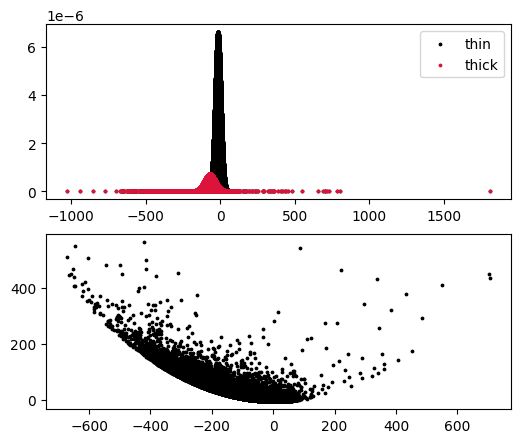

In [30]:
fig, ax = plt.subplots(figsize=[6, 5], nrows=2)

ax[0].scatter(data['V_UVW'], data['p_thin'], s=3, color='black', label='thin')
ax[0].scatter(data['V_UVW'], data['p_thick'], s=3, color='crimson', label='thick')
ax[0].legend()
ax[1].scatter(data['V_UVW'], np.log(data['TD/D']), s=3, color='black')

plt.show()

# Separating according to values of TD/D and TD/H.

Following the criteria of Bensby et al. 2003, to minimize contamination:
- Stars with TD/D < 0.1 will be part of the thin disk.
- Stars with TD/D > 10 will be part of the thin disk.
- Stars with TD/H < 0.1 will be part of the halo.

In [31]:
mask_d = (data['TD/D'] < 0.5) & (data['TD/H'] > 999)
thin = data[mask_d]
thin['flag_thin'] = [1 for item in thin['age']]
thin['flag_thick'] = [0 for item in thin['age']]
thin['flag_halo'] = [0 for item in thin['age']]

/tmp/ipykernel_839341/3241771105.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thin['flag_thin'] = [1 for item in thin['age']]
/tmp/ipykernel_839341/3241771105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thin['flag_thick'] = [0 for item in thin['age']]
/tmp/ipykernel_839341/3241771105.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [32]:
mask_td = (data['TD/D'] > 1)
thick = data[mask_td]
thick['flag_thick'] = [1 for item in thick['age']]
thick['flag_thin'] = [0 for item in thick['age']]
thick['flag_halo'] = [0 for item in thick['age']]

/tmp/ipykernel_839341/990566077.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thick['flag_thick'] = [1 for item in thick['age']]
/tmp/ipykernel_839341/990566077.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thick['flag_thin'] = [0 for item in thick['age']]
/tmp/ipykernel_839341/990566077.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

In [33]:
mask_h = (data['TD/H'] < 1)
halo = data[mask_h]
halo['flag_halo'] = [1 for item in halo['age']]
halo['flag_thick'] = [0 for item in halo['age']]
halo['flag_thin'] = [0 for item in halo['age']]

/tmp/ipykernel_839341/3769412223.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  halo['flag_halo'] = [1 for item in halo['age']]
/tmp/ipykernel_839341/3769412223.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  halo['flag_thick'] = [0 for item in halo['age']]
/tmp/ipykernel_839341/3769412223.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

In [34]:
len(halo), len(thin), len(thick)

(7837, 290118, 63368)

In [35]:
flagged_data = pd.concat([thin, thick, halo], axis=0, ignore_index=True)
flagged_data.keys()

Index(['sobject_id', 'tmass_id_x', 'teff', 'logg', 'fe_h', 'vmic', 'vsini',
       'mass', 'age', 'lbol', 'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe',
       'mg_fe', 'si_fe', 'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe',
       'ni_fe', 'cu_fe', 'zn_fe', 'y_fe', 'snr_px_ccd3', 'tmass_id_y', 'U_UVW',
       'V_UVW', 'W_UVW', 'ALi', 'p_thin', 'p_thick', 'p_halo', 'TD/D', 'TD/H',
       'flag_thin', 'flag_thick', 'flag_halo'],
      dtype='object')

In [36]:
len(flagged_data)

361323

### Checking distribution of different parameters of each population to confirm whether or not the separation was accurate.

### Ages

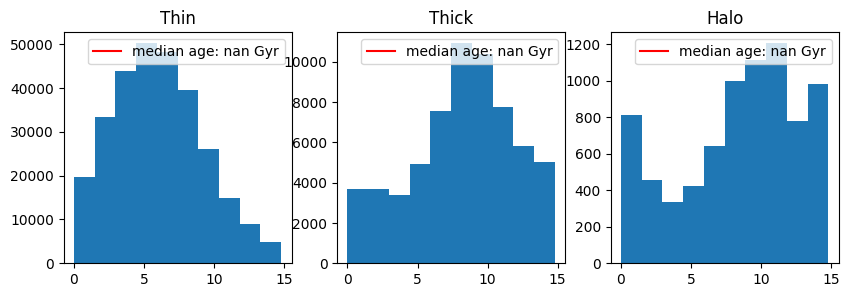

In [37]:
fig, ax = plt.subplots(figsize=[10,3], ncols=3)
ax[0].hist(thin['age'])
ax[0].set_title('Thin')
ax[0].axvline(np.median(thin['age']), c='r', label=f"median age: {np.median(thin['age']):.2f} Gyr")
ax[0].legend()

ax[1].hist(thick['age'])
ax[1].set_title('Thick')
ax[1].axvline(np.median(thick['age']), c='r', label=f"median age: {np.median(thick['age']):.2f} Gyr")
ax[1].legend()

ax[2].hist(halo['age'])
ax[2].set_title('Halo')
ax[2].axvline(np.median(halo['age']), c='r', label=f"median age: {np.median(halo['age']):.2f} Gyr")
ax[2].legend()
plt.show()

### [Fe/H]

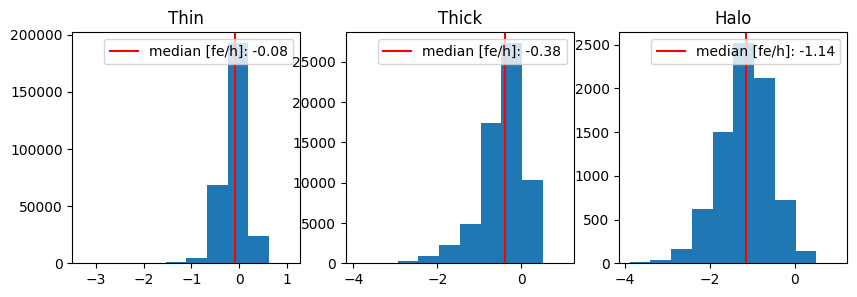

In [38]:
fig, ax = plt.subplots(figsize=[10,3], ncols=3)
ax[0].hist(thin['fe_h'])
ax[0].set_title('Thin')
ax[0].axvline(np.median(thin['fe_h']), c='r', label=f"median [fe/h]: {np.median(thin['fe_h']):.2f}")
ax[0].legend()

ax[1].hist(thick['fe_h'])
ax[1].set_title('Thick')
ax[1].axvline(np.median(thick['fe_h']), c='r', label=f"median [fe/h]: {np.median(thick['fe_h']):.2f}")
ax[1].legend()

ax[2].hist(halo['fe_h'])
ax[2].set_title('Halo')
ax[2].axvline(np.median(halo['fe_h']), c='r', label=f"median [fe/h]: {np.median(halo['fe_h']):.2f}")
ax[2].legend()
plt.show()

# TRAINING

## With probability method.

In [ ]:
#Función para obtener algunas métricas de los árboles de decisión. 
def GetMetrics(y_test, y_pred,clf,Output, name):
    Accuracy = round(metrics.accuracy_score(y_test, y_pred),3)
    Precision = round(metrics.precision_score(y_test, y_pred),3)
    Recall = round(metrics.recall_score(y_test, y_pred),3)
    print("Accuracy:",Accuracy)
    print("Precision:",Precision)
    print("Recall:",Recall)
    Depth = clf.get_depth()
    NLeaves = clf.get_n_leaves()
    Nodes = clf.tree_.node_count
    TerminalNodes = clf.tree_.node_count-clf.get_n_leaves()
    
    MaxFeatures = clf.max_features_
    NFeaturesIn = clf.n_features_in_
    FeaturesNames = clf.feature_names_in_
    
    cm = metrics.confusion_matrix(y_test, y_pred, labels=clf.classes_,normalize='all')
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)
    disp.plot(cmap='PuRd')
    disp.ax_.tick_params(axis='both', which='major', labelsize=13)  # Major ticks size
    disp.ax_.tick_params(axis='both', which='minor', labelsize=13)  # Minor ticks size

    for text in disp.text_.ravel():  # disp.text_ contains the text elements for the matrix
        text.set_fontsize(15)
    
    # Customize the x and y labels
    disp.ax_.set_xlabel('Predicted Class', fontsize=13)  # X-axis label size
    disp.ax_.set_ylabel('Real Class', fontsize=13)
    disp.figure_.subplots_adjust(left=0.05, bottom=0.15, right=0.98, top=0.95,wspace=0.00, hspace=0.05)
    disp.figure_.savefig(Output)
    plt.show()
    return Accuracy,Precision,Depth,NLeaves,Nodes,TerminalNodes,MaxFeatures,NFeaturesIn,FeaturesNames

In [ ]:
flagged_data = flagged_data.drop(columns=['sobject_id', 'tmass_id_x', 'tmass_id_y', 'TD/D', 
                                          'TD/H', 'p_thin', 'p_thick', 'p_halo', 'snr_px_ccd3',
                                       'U_UVW', 'V_UVW', 'W_UVW','p_thin',
                                           'p_thick', 'p_halo', 'TD/D', 'TD/H',])

In [ ]:
flagged_data.keys()

## THIN DISK MEMBERSHIP

In [103]:
X_train, X_test, y_train, y_test = train_test_split(flagged_data.drop(columns=['flag_thin', 'flag_thick', 'flag_halo']), flagged_data['flag_thin'], test_size=0.7, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train),len(y_train),len(X_test),len(y_test)

(108396, 108396, 252927, 252927)

In [104]:
# Create Decision Tree classifer object[
clf = DecisionTreeClassifier(criterion='gini',
                             max_depth=5,
                             min_samples_split=2,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)


#Predict the response for test dataset
y_pred = clf.predict(X_test)

print(GetMetrics(y_test, y_pred,clf,'thin_matrix.png', 'thin'))

ValueError: could not convert string to float: '08013812-2330288'

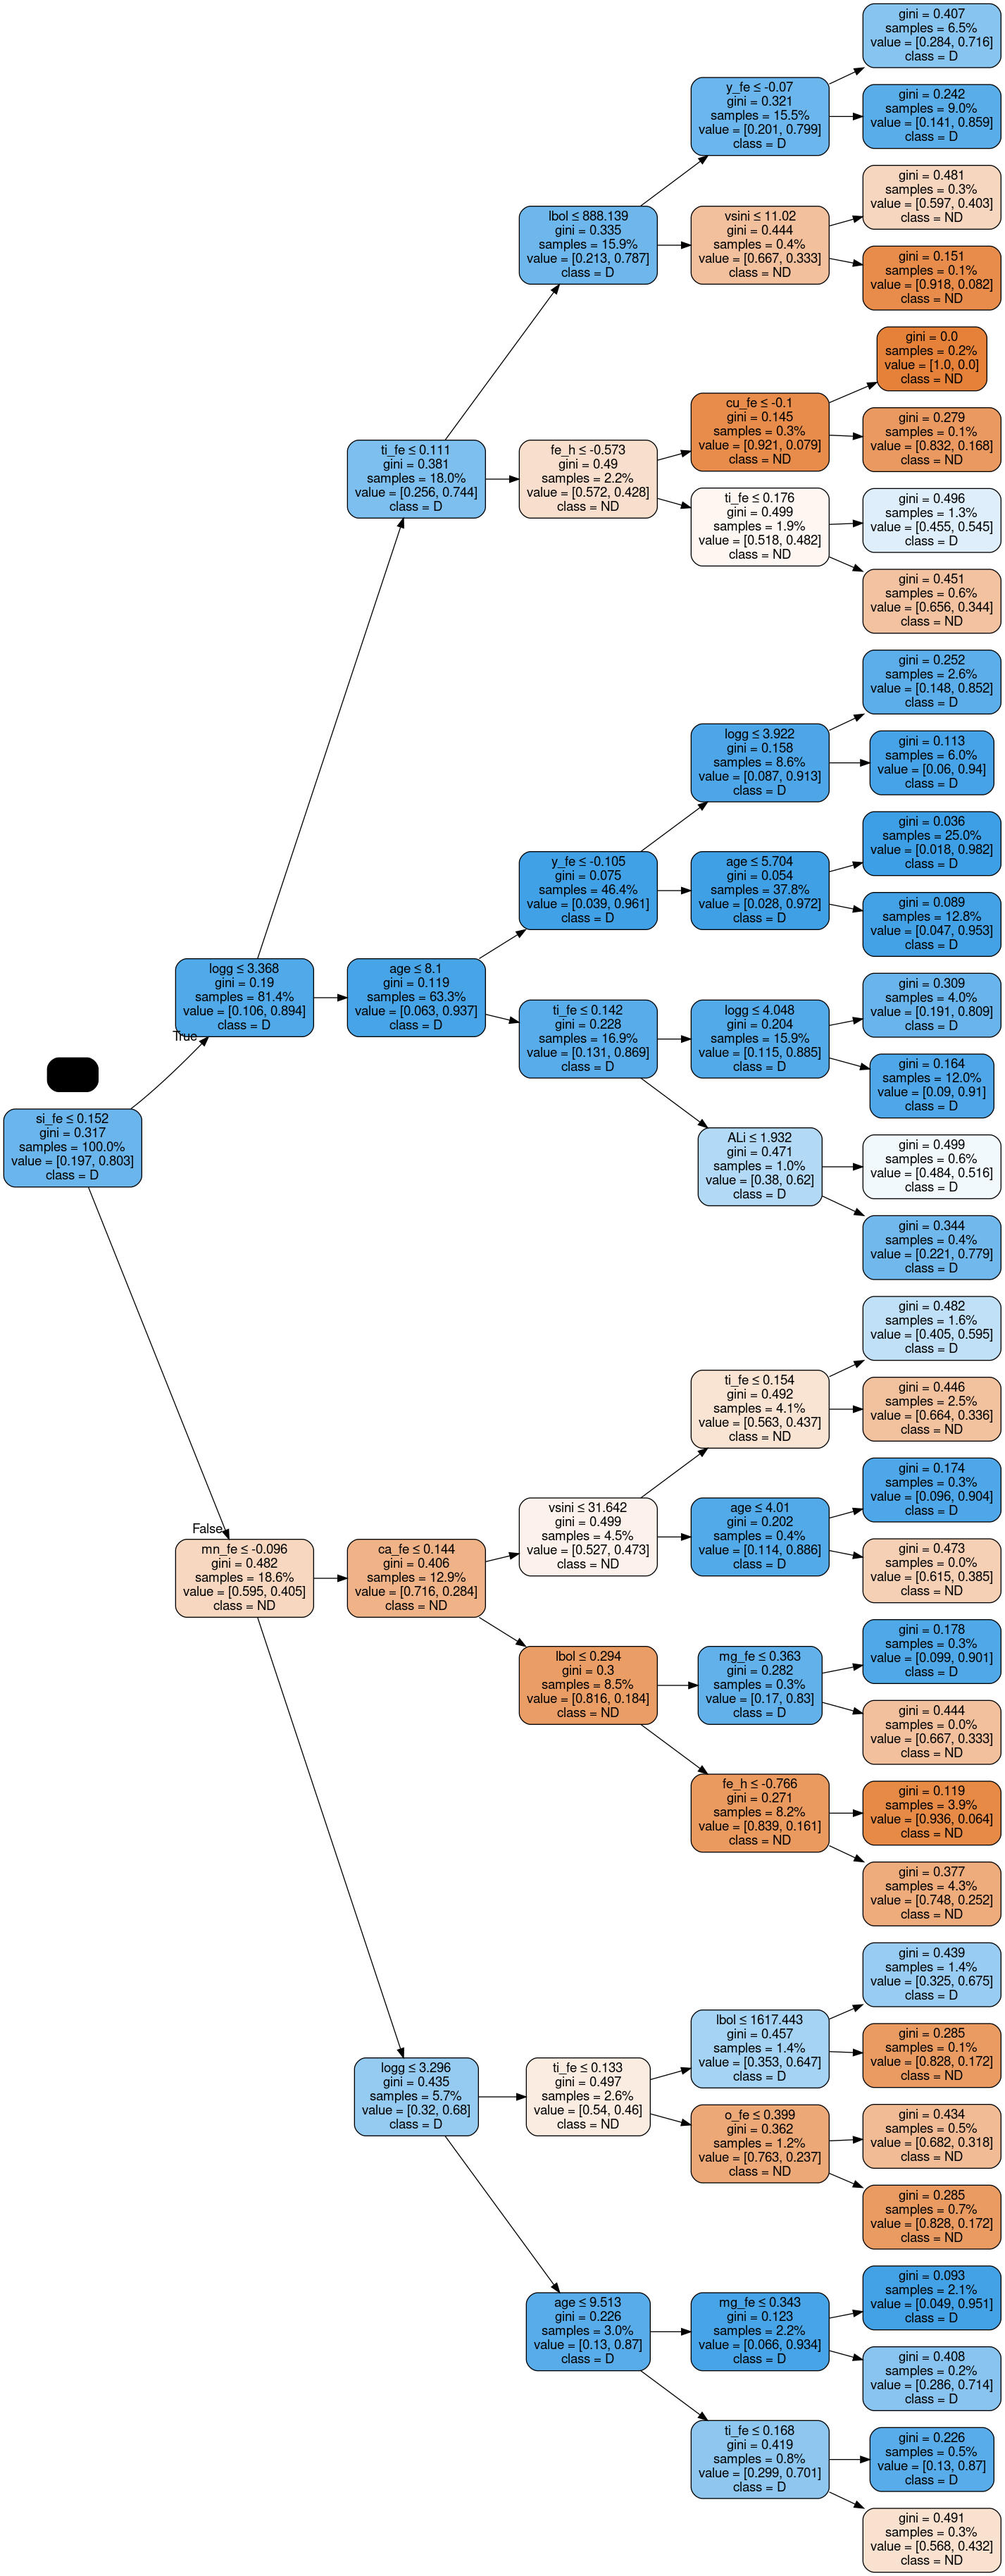

In [45]:
dot_data = StringIO()

export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = flagged_data.drop(columns=['flag_thick', 'flag_thin', 'flag_halo']).columns,class_names=['ND','D'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

## THICK DISK MEMBERSHIP

In [105]:
X_train_thick, X_test_thick, y_train_thick, y_test_thick = train_test_split(flagged_data.drop(columns=['flag_thin', 'flag_thick', 'flag_halo']), flagged_data['flag_thick'], test_size=0.7, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_thick),len(y_train_thick),len(X_test_thick),len(y_test_thick)

(108396, 108396, 252927, 252927)

In [106]:
# Create Decision Tree classifer object[
clf = DecisionTreeClassifier(criterion='gini',
                             max_depth=5,
                             min_samples_split=2,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf = clf.fit(X_train_thick,y_train_thick)


#Predict the response for test dataset
y_pred_thick = clf.predict(X_test_thick)

print(GetMetrics(y_test_thick, y_pred_thick,clf,'CM_GINI.pdf', 'name'))

ValueError: could not convert string to float: '21481367-2234453'

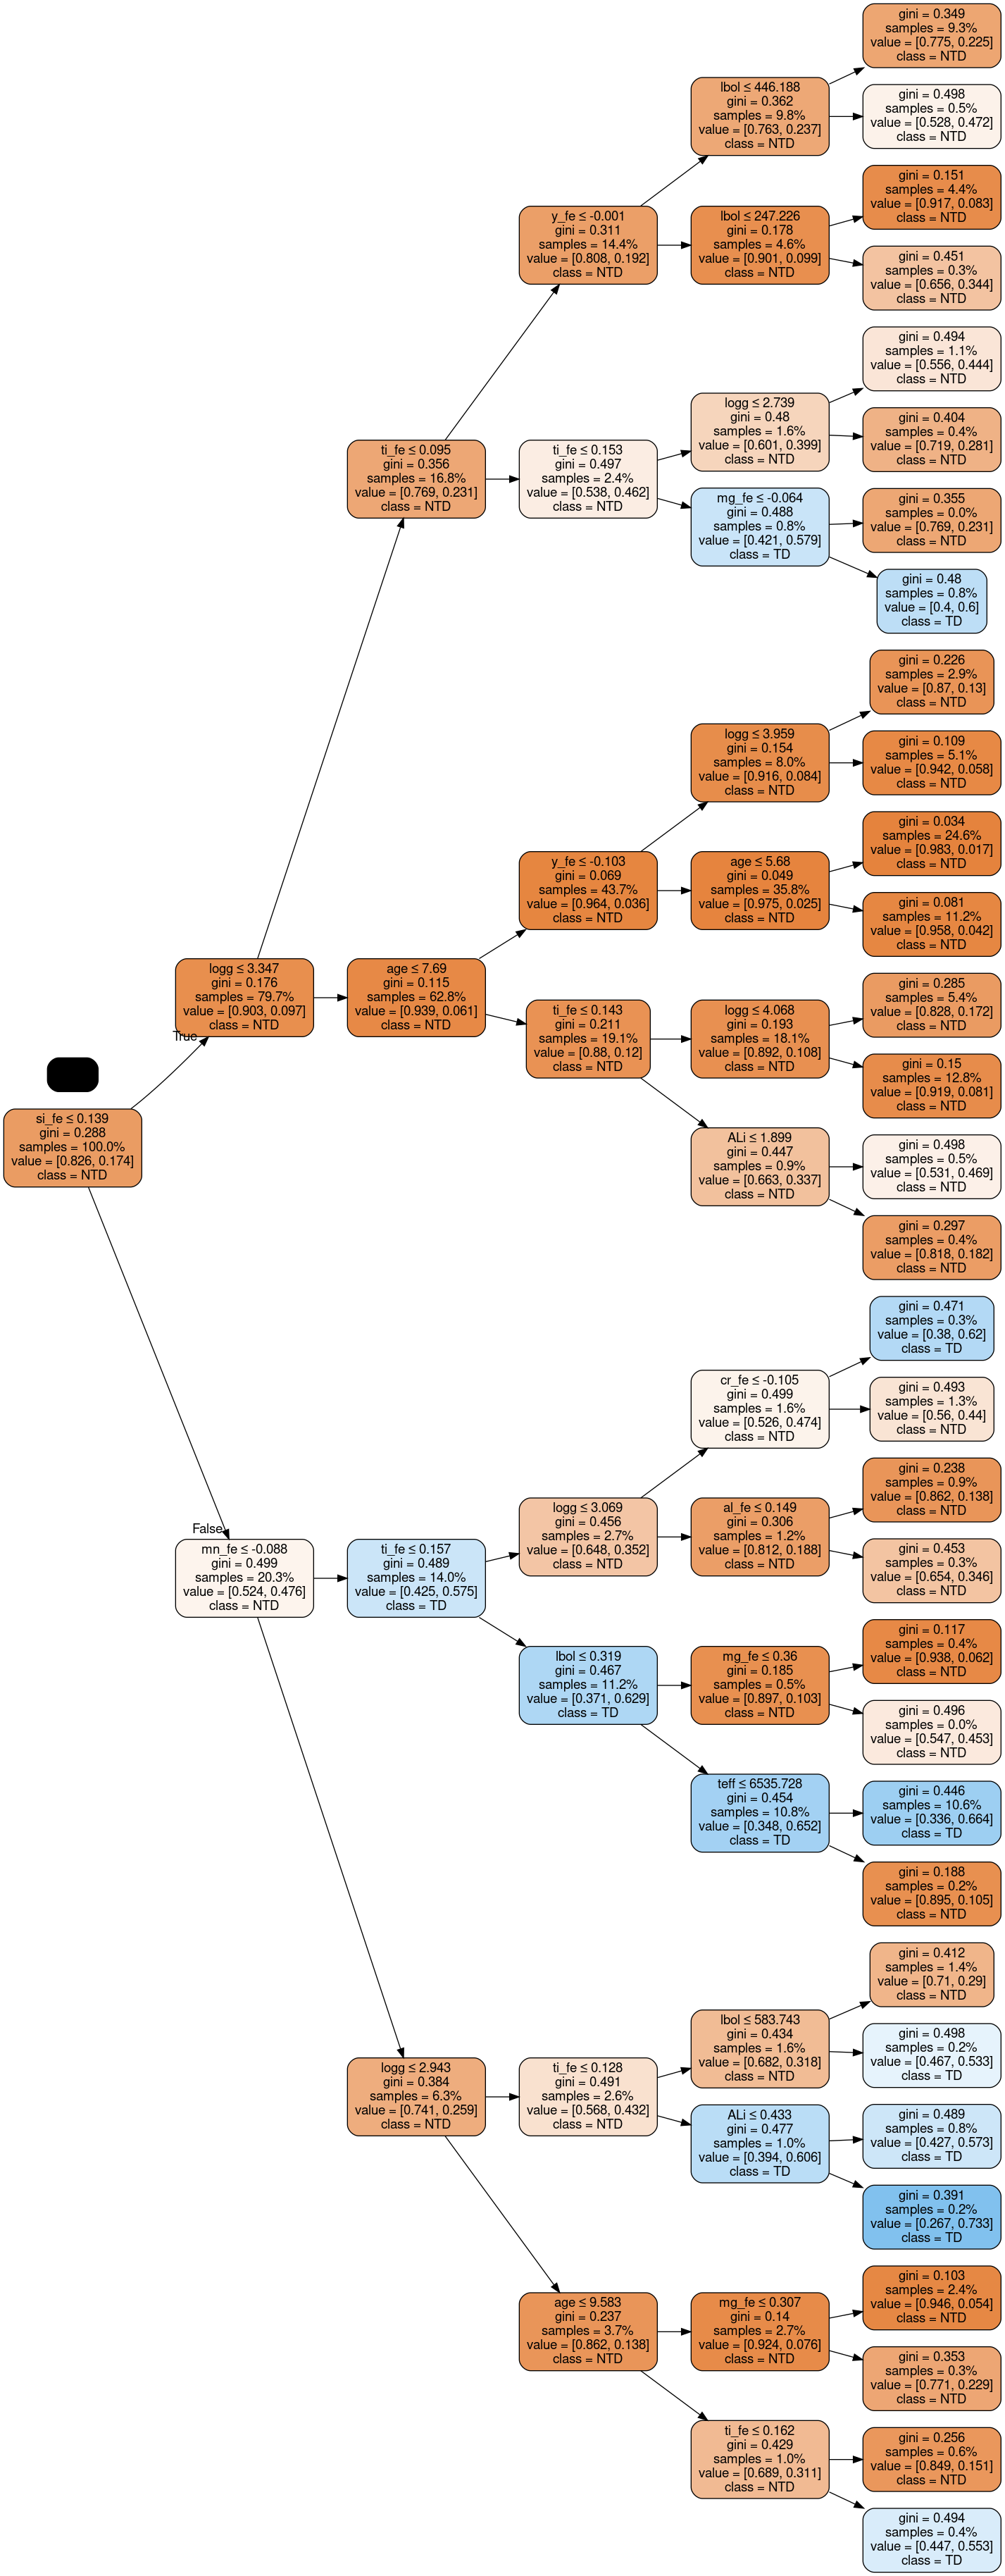

In [52]:
dot_data = StringIO()

export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = flagged_data.drop(columns=['flag_thick', 'flag_thin', 'flag_halo']).columns,class_names=['NTD','TD'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

## HALO MEMBERSHIP

In [54]:
X_train_halo, X_test_halo, y_train_halo, y_test_halo = train_test_split(flagged_data.drop(columns=['flag_thin', 'flag_thick', 'flag_halo']), flagged_data['flag_halo'], test_size=0.7, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_halo),len(y_train_halo),len(X_test_halo),len(y_test_halo)

(108396, 108396, 252927, 252927)

Accuracy: 0.978
Precision: 0.307
Recall: 0.015


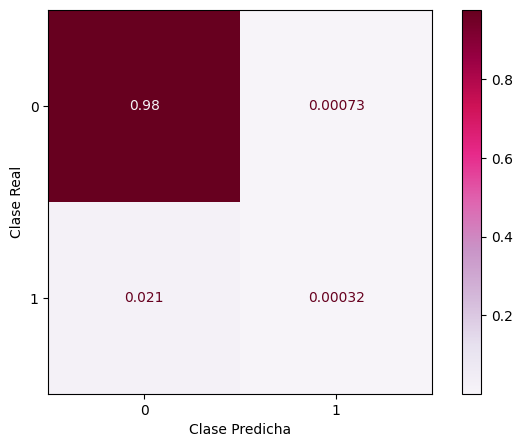

(0.978, 0.307, 5, 31, 61, 30, 27, 27, array(['teff', 'logg', 'fe_h', 'vmic', 'vsini', 'mass', 'age', 'lbol',
       'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe', 'mg_fe', 'si_fe',
       'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe', 'ni_fe',
       'cu_fe', 'zn_fe', 'y_fe', 'ALi'], dtype=object))


In [55]:
# Create Decision Tree classifer object[
clf = DecisionTreeClassifier(criterion='gini',
                             max_depth=5,
                             min_samples_split=2,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf = clf.fit(X_train_halo,y_train_halo)


#Predict the response for test dataset
y_pred_halo = clf.predict(X_test_halo)

print(GetMetrics(y_test_halo, y_pred_halo,clf,'CM_GINI.pdf', 'bna'))

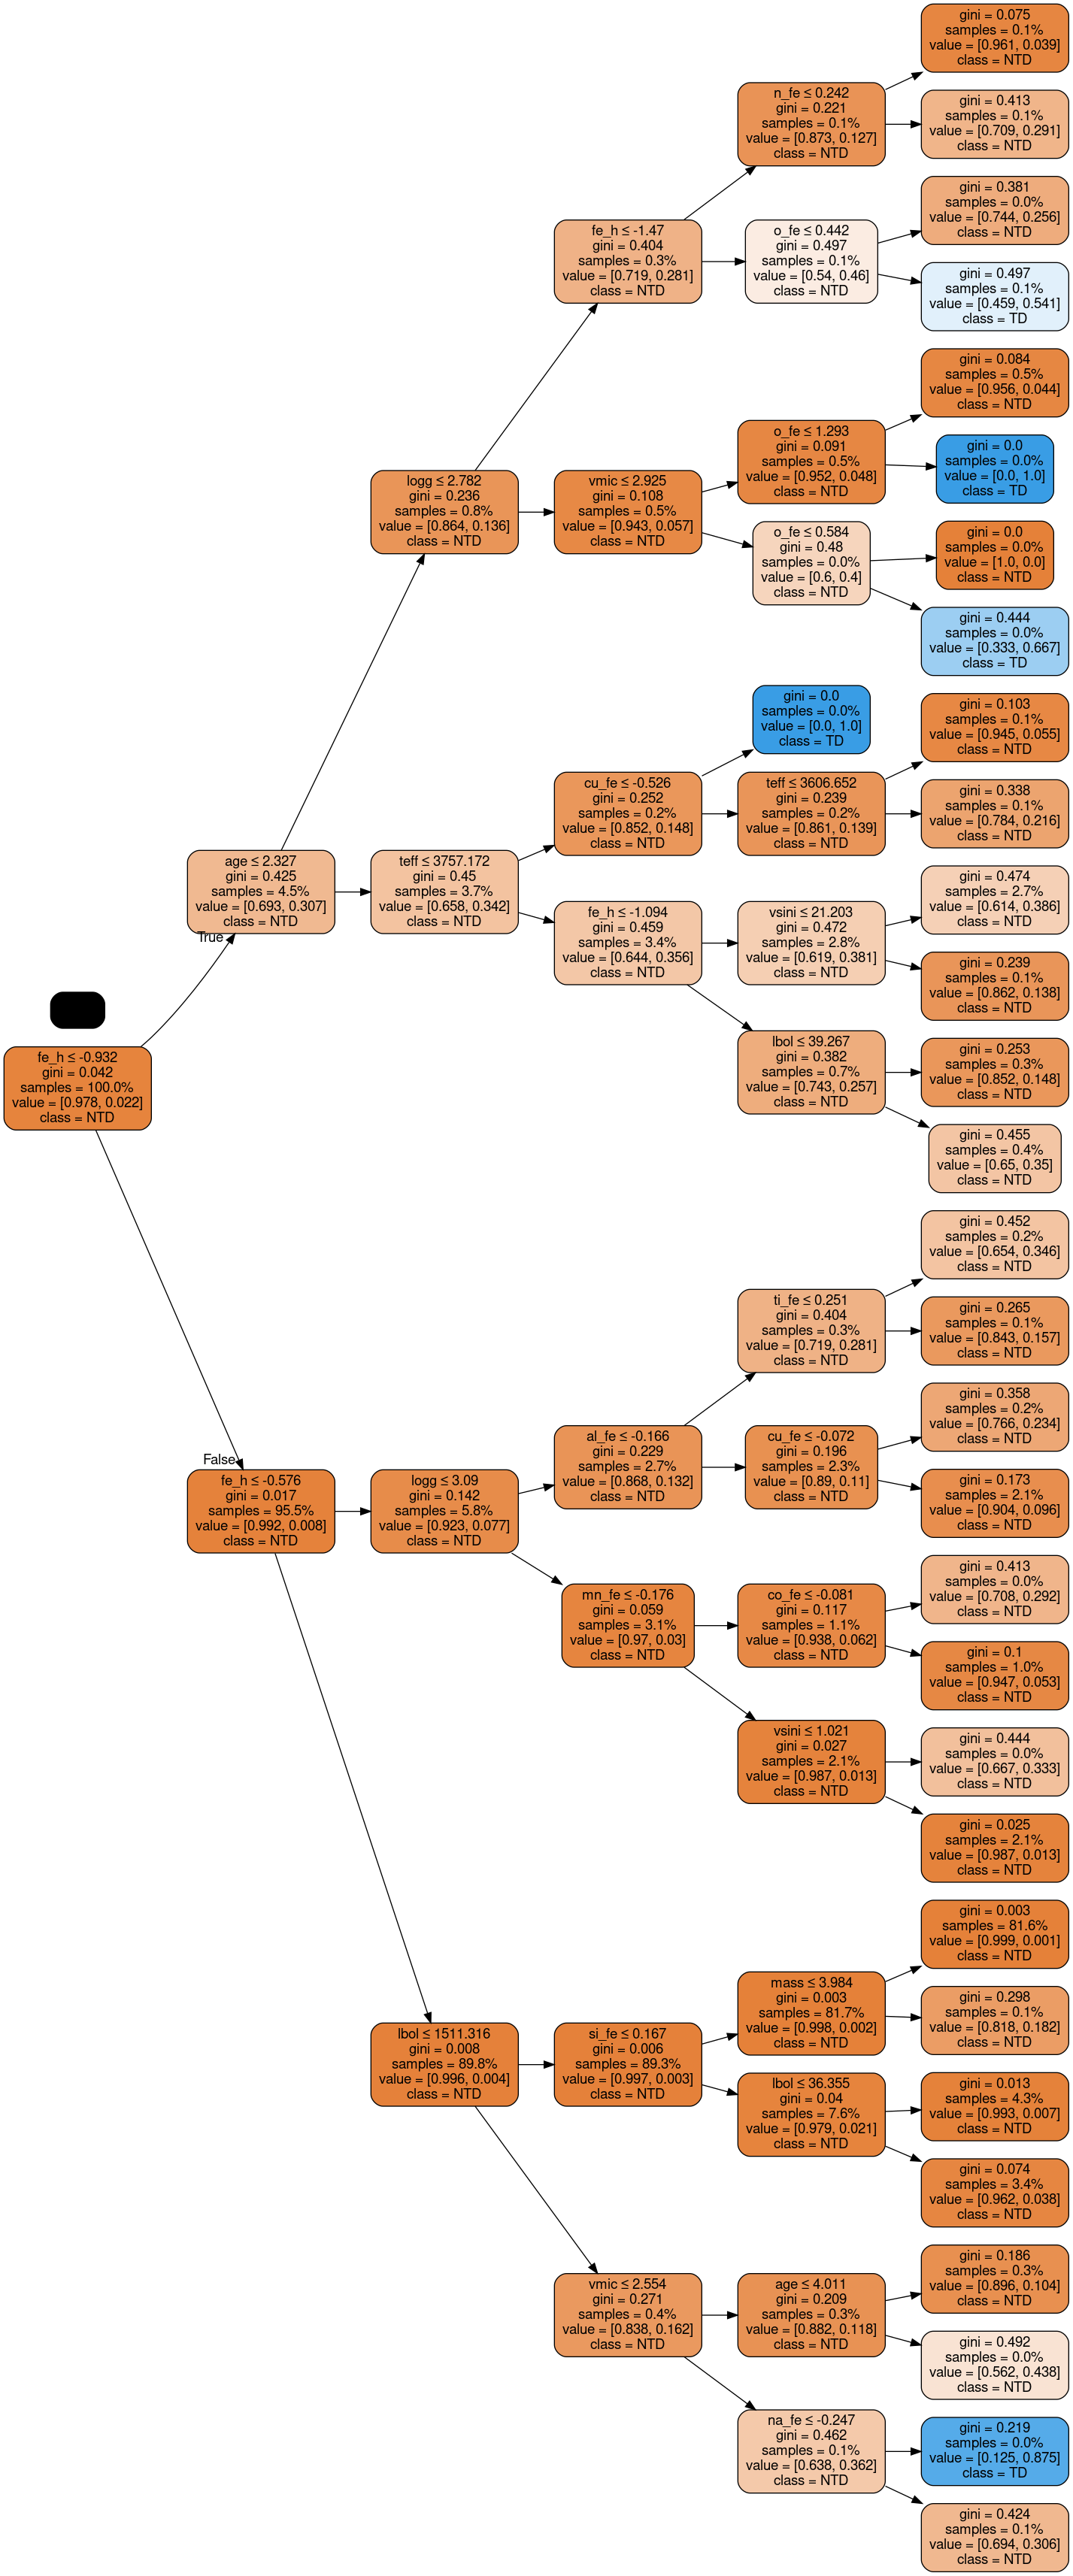

In [56]:
dot_data = StringIO()

export_graphviz(clf, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = flagged_data.drop(columns=['flag_thick', 'flag_thin', 'flag_halo']).columns,class_names=['NTD','TD'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

## With Toomre Diagram.

### BALANCING

In [ ]:
len(data_toomre[data_toomre['flag_thick'] == 1]), len(data_toomre[data_toomre['flag_thin'] == 1]), len(data_toomre[data_toomre['flag_halo'] == 1])

In [ ]:
halos = data_toomre[data_toomre['flag_halo'] == 1]
duplicated_halos = pd.concat([halos] * 16, ignore_index=True)
balanced_data = pd.concat([data_toomre, duplicated_halos], ignore_index=True)

In [ ]:
data_toomre_flagless = data_toomre.drop(columns=[col for col in balanced_data.columns if 'flag' in col or 'id' in col or 'UVW' in col
                                                or 'snr' in col or 'magnitude' in col or 'TD/D' in col or 'TD/H' in col or 'p_thin' in col
                                                or 'p_thick' in col or 'p_halo' in col])

### THIN DISK MEMBERSHIP

In [ ]:
balanced_data_flagless = balanced_data.drop(columns=[col for col in balanced_data.columns if 'flag' in col or 'id' in col or 'UVW' in col
                                                or 'snr' in col or 'magnitude' in col or 'TD/D' in col or 'TD/H' in col or 'p_thin' in col
                                                or 'p_thick' in col or 'p_halo' in col])

In [69]:
X_train_thin, X_test_thin, y_train_thin, y_test_thin = train_test_split(balanced_data_flagless, balanced_data['flag_thin'], test_size=0.5, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_thin),len(y_train_thin),len(X_test_thin),len(y_test_thin)

(287685, 287685, 287685, 287685)

In [70]:
print(y_train_thin.value_counts())


flag_thin
0    196582
1     91103
Name: count, dtype: int64


1 0.5110150516233363
2 0.5208053261634978
3 0.5535390955066702
4 0.5612663304031693
5 0.5593164685118551
6 0.5638592028314278
7 0.5620096013985536
8 0.5642679525752518
9 0.5662651432666731
10 0.5677109965588247
11 0.5702419646081618
12 0.5733874313520051
13 0.5754772445546308
14 0.5784630403261697
15 0.5826265459831832
16 0.5876375825869642
17 0.5929720575783235
18 0.5964557200348309
19 0.6028438164372266


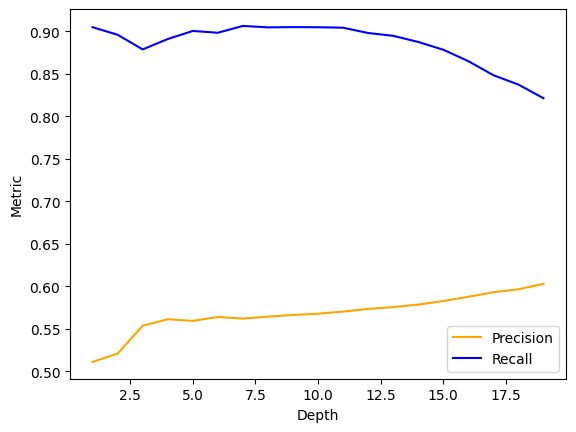

In [71]:
Precision = []
Recall = []
depths = []

for m in np.arange(1,20,1):
    
    # Create Decision Tree classifer object
    clf = RandomForestClassifier(n_estimators=20, criterion='gini',
                                 max_depth=m,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 class_weight='balanced',
                                 ccp_alpha=0)
    # Train Decision Tree Classifer
    with parallel_backend('threading', n_jobs=3):
        clf = clf.fit(X_train_thin,y_train_thin)
    
    #Predict the response for test dataset
    y_pred_thin = clf.predict(X_test_thin)
    Accuracy = metrics.accuracy_score(y_test_thin, y_pred_thin)
    precision = metrics.precision_score(y_test_thin, y_pred_thin)
    recall = metrics.recall_score(y_test_thin, y_pred_thin)
    print(m,precision)
    Precision.append(precision)
    Recall.append(recall)
    depths.append(m)
plt.plot(depths, Precision, c='orange', label='Precision')
plt.plot(depths, Recall, c='blue', label='Recall')
plt.xlabel('Depth')
plt.ylabel('Metric')
plt.legend()
plt.show()

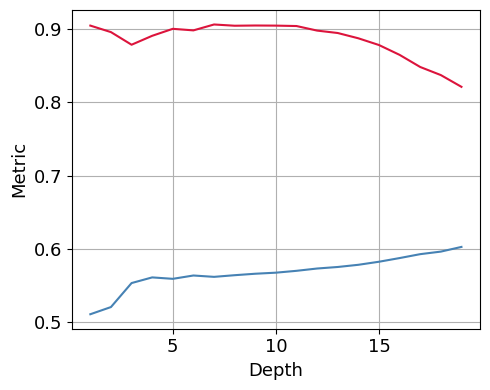

In [73]:
fig, ax = plt.subplots(figsize=[5, 4])
ax.plot(depths, Precision, c='steelblue', label='Precision')
ax.plot(depths, Recall, c='crimson', label='Recall')
ax.set_xlabel('Depth', fontsize=13)
ax.set_ylabel('Metric', fontsize=13)
ax.tick_params(labelsize=13)
ax.grid()
fig.tight_layout()
plt.savefig('metrics_thin.png')
plt.show()


intentar n estimator bajo

Accuracy: 0.736
Precision: 0.557
Recall: 0.816


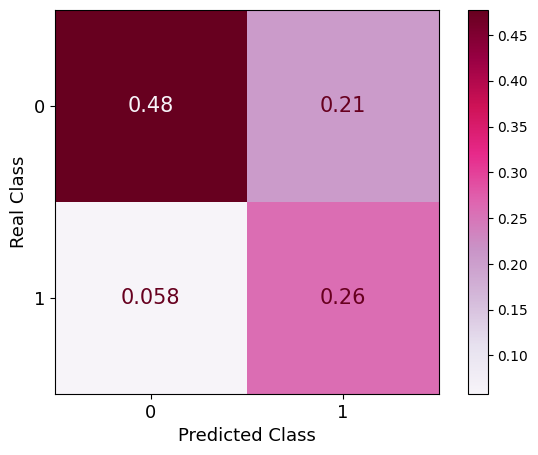

(0.736, 0.557, 2, 4, 7, 3, 27, 27, array(['teff', 'logg', 'fe_h', 'vmic', 'vsini', 'mass', 'age', 'lbol',
       'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe', 'mg_fe', 'si_fe',
       'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe', 'ni_fe',
       'cu_fe', 'zn_fe', 'y_fe', 'ALi'], dtype=object))


In [111]:
# Create Decision Tree classifer object[
clf_thin = DecisionTreeClassifier(criterion='gini',
                             max_depth=2,
                             min_samples_split=2,
                             min_samples_leaf=1,
                            class_weight='balanced',
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf_thin = clf_thin.fit(X_train_thin, y_train_thin)


#Predict the response for test dataset
y_pred_thin = clf_thin.predict(X_test_thin)

print(GetMetrics(y_test_thin, y_pred_thin,clf_thin,'thin_matrix.png', 'thin'))

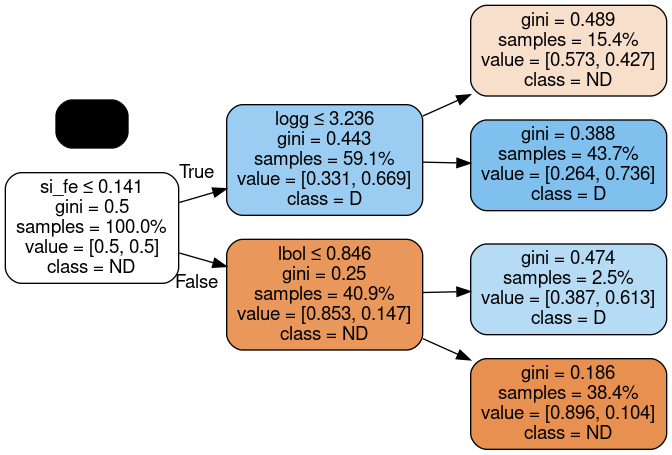

In [54]:
dot_data = StringIO()

export_graphviz(clf_thin, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = balanced_data_flagless.columns,  class_names=['ND','D'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

In [55]:
clf_thin = RandomForestClassifier(n_estimators=200,criterion='gini',
                             max_depth=2,
                             min_samples_split=2,
                             min_samples_leaf=1,
                             class_weight='balanced',
                             ccp_alpha=0)
# Train Decision Tree Classifer
#with parallel_backend('threading', n_jobs=4):
clf_thin = clf_thin.fit(X_train_thin,y_train_thin)

#Predict the response for test dataset
y_pred_thin = clf_thin.predict(X_test_thin)
Accuracy = metrics.accuracy_score(y_test_thin, y_pred_thin)
Precision = metrics.precision_score(y_test_thin, y_pred_thin)
Recall = metrics.recall_score(y_test_thin, y_pred_thin)
print("Accuracy:",Accuracy)
print("Precision:",Precision)
print("Recall:",Recall)

Accuracy: 0.7378556407181466
Precision: 0.5572469670962674
Recall: 0.8404949702162203


Checking importance.

In [56]:
columns = balanced_data_flagless.columns.tolist()
columns = np.array(columns)
Importance = clf_thin.feature_importances_


print(np.around(Importance,1),columns)
columns_2_use = np.array(columns)

columns = columns[np.argsort(Importance)[::-1]]
Importance = Importance[np.argsort(Importance)[::-1]]
for i in range(len(Importance)):
    if round(Importance[i],1)>0:
        print(columns[i],round(Importance[i],3))

[0.  0.1 0.1 0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.2 0.1 0.1
 0.  0.  0.  0.  0.  0.  0.  0.  0. ] ['teff' 'logg' 'fe_h' 'vmic' 'vsini' 'mass' 'age' 'lbol' 'c_fe' 'n_fe'
 'o_fe' 'na_fe' 'al_fe' 'k_fe' 'mg_fe' 'si_fe' 'ca_fe' 'ti_fe' 'sc_fe'
 'cr_fe' 'mn_fe' 'co_fe' 'ni_fe' 'cu_fe' 'zn_fe' 'y_fe' 'ALi']
si_fe 0.186
mg_fe 0.141
logg 0.119
fe_h 0.113
ti_fe 0.102
ca_fe 0.079
lbol 0.077


### THICK DISK MEMBERSHIP

In [118]:
X_train_thick, X_test_thick, y_train_thick, y_test_thick = train_test_split(data_toomre_flagless, data_toomre['flag_thick'], test_size=0.5, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_thick),len(y_train_thick),len(X_test_thick),len(y_test_thick)

(192669, 192669, 192669, 192669)

Accuracy: 0.627
Precision: 0.627
Recall: 0.611


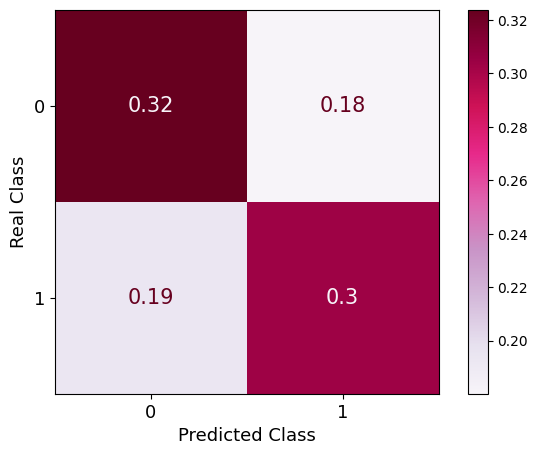

(0.627, 0.627, 4, 16, 31, 15, 27, 27, array(['teff', 'logg', 'fe_h', 'vmic', 'vsini', 'mass', 'age', 'lbol',
       'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe', 'mg_fe', 'si_fe',
       'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe', 'ni_fe',
       'cu_fe', 'zn_fe', 'y_fe', 'ALi'], dtype=object))


In [119]:
# Create Decision Tree classifer object[
clf_thick = DecisionTreeClassifier(criterion='gini',
                             max_depth=4,
                             min_samples_split=2,
                             min_samples_leaf=1,
                            class_weight='balanced',
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf_thick = clf_thick.fit(X_train_thick, y_train_thick)


#Predict the response for test dataset
y_pred_thick = clf_thick.predict(X_test_thick)

print(GetMetrics(y_test_thick, y_pred_thick,clf_thick,'thick_matrix.png', 'name'))

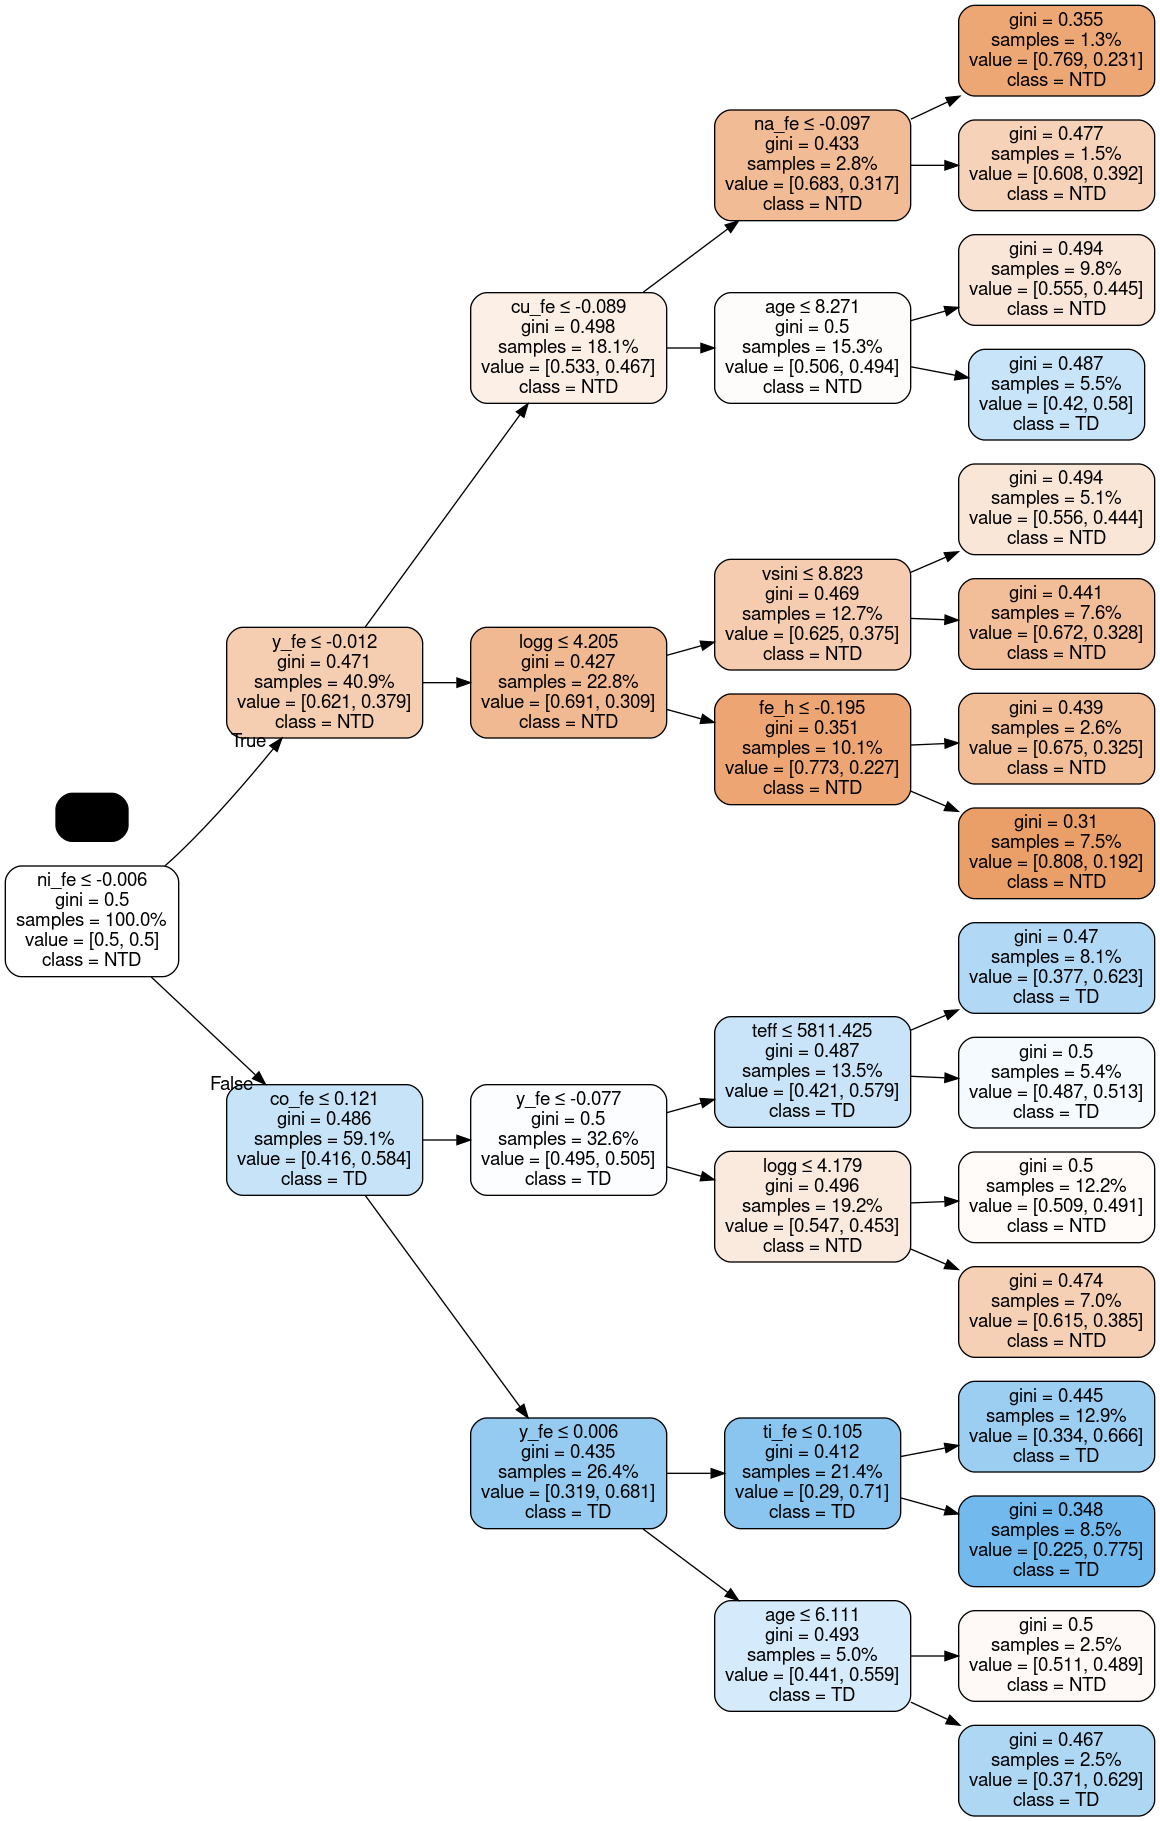

In [59]:
dot_data = StringIO()

export_graphviz(clf_thick, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = balanced_data_flagless.columns,  class_names=['NTD','TD'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

In [ ]:
Precision = []
Recall = []
depths = []

for m in np.arange(1,20,1):
    
    # Create Decision Tree classifer object
    clf = RandomForestClassifier(n_estimators=20, criterion='gini',
                                 max_depth=m,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 class_weight='balanced',
                                 ccp_alpha=0)
    # Train Decision Tree Classifer
    with parallel_backend('threading', n_jobs=3):
        clf = clf.fit(X_train_thick,y_train_thick)
    
    #Predict the response for test dataset
    y_pred_thick = clf.predict(X_test_thick)
    Accuracy = metrics.accuracy_score(y_test_thick, y_pred_thick)
    precision = metrics.precision_score(y_test_thick, y_pred_thick)
    recall = metrics.recall_score(y_test_thick, y_pred_thick)
    print(m,precision)
    Precision.append(precision)
    Recall.append(recall)
    depths.append(m)
plt.plot(depths,Precision, c='orange', label='Precision')
plt.plot(depths, Recall, c='blue', label='Recall')
plt.xlabel('Depth')
plt.ylabel('Metric')
plt.legend()
plt.show()

In [60]:
clf_thick = RandomForestClassifier(n_estimators=200,criterion='gini',
                             max_depth=15,
                             min_samples_split=2,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
with parallel_backend('threading', n_jobs=4):
    clf_thick = clf_thick.fit(X_train_thin,y_train_thin)

#Predict the response for test dataset
y_pred_thin = clf_thick.predict(X_test_thin)
Accuracy = metrics.accuracy_score(y_test_thin, y_pred_thin)
Precision = metrics.precision_score(y_test_thin, y_pred_thin)
Recall = metrics.recall_score(y_test_thin, y_pred_thin)
print("Accuracy:",Accuracy)
print("Precision:",Precision)
print("Recall:",Recall)

Accuracy: 0.7897839651007178
Precision: 0.6678373321954902
Recall: 0.669624932808232


In [61]:
columns = balanced_data_flagless.columns.tolist()
columns = np.array(columns)
Importance = clf_thick.feature_importances_


print(np.around(Importance,1),columns)
columns_2_use = np.array(columns)

columns = columns[np.argsort(Importance)[::-1]]
Importance = Importance[np.argsort(Importance)[::-1]]
for i in range(len(Importance)):
    if round(Importance[i],1)>0:
        print(columns[i],round(Importance[i],3))

[0.  0.1 0.1 0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.1 0.1 0.1
 0.  0.  0.  0.  0.  0.  0.  0.  0. ] ['teff' 'logg' 'fe_h' 'vmic' 'vsini' 'mass' 'age' 'lbol' 'c_fe' 'n_fe'
 'o_fe' 'na_fe' 'al_fe' 'k_fe' 'mg_fe' 'si_fe' 'ca_fe' 'ti_fe' 'sc_fe'
 'cr_fe' 'mn_fe' 'co_fe' 'ni_fe' 'cu_fe' 'zn_fe' 'y_fe' 'ALi']
si_fe 0.092
logg 0.089
fe_h 0.084
mg_fe 0.083
ti_fe 0.08
lbol 0.078
ca_fe 0.055


### HALO MEMBERSHIP

In [62]:
X_train_halo, X_test_halo, y_train_halo, y_test_halo = train_test_split(balanced_data_flagless, balanced_data['flag_halo'], test_size=0.5, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_halo),len(y_train_halo),len(X_test_halo),len(y_test_halo)

(287685, 287685, 287685, 287685)

Accuracy: 0.869
Precision: 0.817
Recall: 0.806


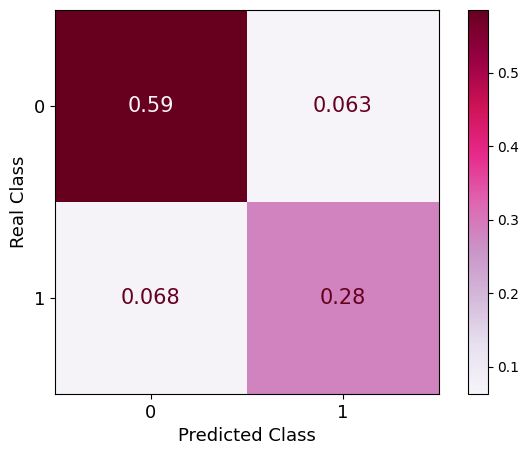

(0.869, 0.817, 2, 4, 7, 3, 27, 27, array(['teff', 'logg', 'fe_h', 'vmic', 'vsini', 'mass', 'age', 'lbol',
       'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe', 'mg_fe', 'si_fe',
       'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe', 'ni_fe',
       'cu_fe', 'zn_fe', 'y_fe', 'ALi'], dtype=object))


In [120]:
# Create Decision Tree classifer object[
clf_halo = DecisionTreeClassifier(criterion='gini',
                             max_depth=2,
                             min_samples_split=2,
                             min_samples_leaf=1,
                            class_weight='balanced',
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf_halo = clf_halo.fit(X_train_halo, y_train_halo)


#Predict the response for test dataset
y_pred_halo = clf_halo.predict(X_test_halo)

print(GetMetrics(y_test_halo, y_pred_halo,clf_halo,'halo_matrix.png', 'halo'))

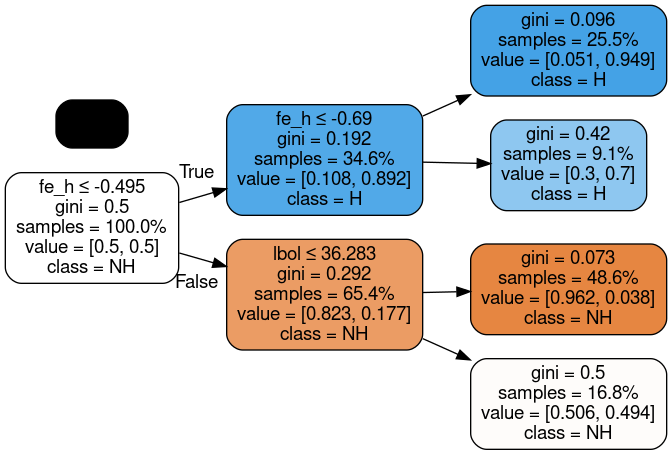

In [66]:
dot_data = StringIO()

export_graphviz(clf_halo, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True,feature_names = balanced_data_flagless.columns,  class_names=['NH','H'],proportion=True,rotate=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('TreeX.png')
Image(graph.create_png())

In [67]:
clf_halo = RandomForestClassifier(n_estimators=200,criterion='gini',
                             max_depth=2,
                             min_samples_split=2,
                             min_samples_leaf=1,
                                  class_weight='balanced',
                             ccp_alpha=0)
# Train Decision Tree Classifer
clf_halo = clf_halo.fit(X_train_halo,y_train_halo)

#Predict the response for test dataset
y_pred_thin = clf_halo.predict(X_test_halo)
Accuracy = metrics.accuracy_score(y_test_halo, y_pred_halo)
Precision = metrics.precision_score(y_test_halo, y_pred_halo)
Recall = metrics.recall_score(y_test_halo, y_pred_halo)
print("Accuracy:",Accuracy)
print("Precision:",Precision)
print("Recall:",Recall)

Accuracy: 0.8686480004171229
Precision: 0.817479352527371
Recall: 0.8060577275111072


In [68]:
columns = balanced_data_flagless.columns.tolist()
columns = np.array(columns)
Importance = clf_halo.feature_importances_


print(np.around(Importance,1),columns)
columns_2_use = np.array(columns)

columns = columns[np.argsort(Importance)[::-1]]
Importance = Importance[np.argsort(Importance)[::-1]]
for i in range(len(Importance)):
    if round(Importance[i],1)>0:
        print(columns[i],round(Importance[i],3))

[0.  0.1 0.2 0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.2 0.1 0.1
 0.  0.  0.  0.  0.  0.  0.  0.  0. ] ['teff' 'logg' 'fe_h' 'vmic' 'vsini' 'mass' 'age' 'lbol' 'c_fe' 'n_fe'
 'o_fe' 'na_fe' 'al_fe' 'k_fe' 'mg_fe' 'si_fe' 'ca_fe' 'ti_fe' 'sc_fe'
 'cr_fe' 'mn_fe' 'co_fe' 'ni_fe' 'cu_fe' 'zn_fe' 'y_fe' 'ALi']
si_fe 0.197
fe_h 0.182
ca_fe 0.112
mg_fe 0.106
ti_fe 0.097
logg 0.076
lbol 0.064


# PARTE 2: PREDECIR MG/FE

In [52]:
balanced_data_flagless_drop = balanced_data_flagless.dropna()
len(balanced_data_flagless_drop)

434765

Using RandomForest to predict values of Mg/Fe.

In [53]:
X_train_mgfe, X_test_mgfe, y_train_mgfe, y_test_mgfe = train_test_split(balanced_data_flagless_drop.drop(columns=['mg_fe', 'si_fe', 'ti_fe']), balanced_data_flagless_drop['mg_fe'], test_size=0.7, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_mgfe),len(y_train_mgfe),len(X_test_mgfe),len(y_test_mgfe)

(130429, 130429, 304336, 304336)

In [55]:
rlf = RandomForestRegressor(n_estimators=20,criterion='squared_error',
                             max_depth=20,
                             min_samples_split=4,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
rlf = rlf.fit(X_train_mgfe, y_train_mgfe)

#Predict the response for test dataset
y_pred_mgfe = rlf.predict(X_test_mgfe)
mae = mean_absolute_error(y_test_mgfe, y_pred_mgfe)
mse = mean_squared_error(y_test_mgfe, y_pred_mgfe)
r2 = r2_score(y_test_mgfe, y_pred_mgfe)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 0.029830798840913515
Mean Squared Error (MSE): 0.0022960950026261395
R² Score: 0.8909544674892375


1 0.5233220765278315
2 0.6112557530429379
3 0.6482116974546637
4 0.6770426816788296
5 0.7052595660092834
6 0.7335254732273251
7 0.7578602067876239
8 0.7804578840548659
9 0.8005536662971988
10 0.8184019503052602
11 0.8323489102143156
12 0.844168925748763
13 0.857567500222896
14 0.8665211350441144
15 0.8728345691606637
16 0.8785731337108017
17 0.8838474255901384
18 0.8867002844755061
19 0.8888051238858137


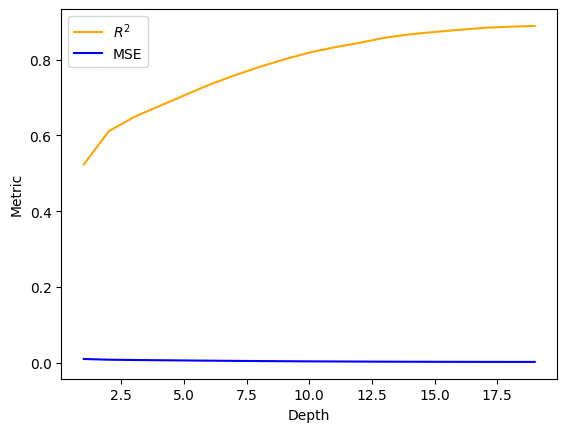

In [74]:
R2s = []
MSEs = []
depths = []

for m in np.arange(1,20,1):
    
    # Create Decision Tree classifer object
    clf = RandomForestRegressor(n_estimators=20, criterion='squared_error',
                                 max_depth=m,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 ccp_alpha=0)
    # Train Decision Tree Classifer
    with parallel_backend('threading', n_jobs=3):
        clf = clf.fit(X_train_mgfe,y_train_mgfe)
    
    #Predict the response for test dataset
    y_pred_mgfe = clf.predict(X_test_mgfe)
    mse = mean_squared_error(y_test_mgfe, y_pred_mgfe)
    r2 = r2_score(y_test_mgfe, y_pred_mgfe)
    print(m,r2)
    MSEs.append(mse)
    R2s.append(r2)
    depths.append(m)
plt.plot(depths,R2s, c='orange', label='$R^2$')
plt.plot(depths, MSEs, c='blue', label='MSE')
plt.xlabel('Depth')
plt.ylabel('Metric')
plt.legend()
plt.show()

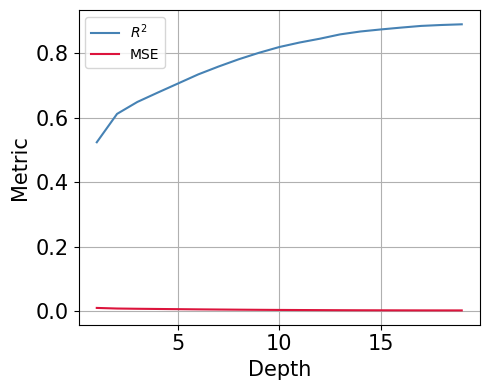

In [124]:
fig, ax = plt.subplots(figsize=[5, 4])

ax.plot(depths,R2s, c='steelblue', label='$R^2$')
ax.plot(depths, MSEs, c='crimson', label='MSE')
ax.set_xlabel('Depth', fontsize=15)
ax.set_ylabel('Metric', fontsize=15)
ax.tick_params(labelsize=15)
ax.grid()
fig.tight_layout()
plt.legend()
plt.savefig('metric_mgfe.png')
plt.show()

In [76]:
rlf = RandomForestRegressor(n_estimators=200,criterion='squared_error',
                             max_depth=18,
                             min_samples_split=4,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
rlf = rlf.fit(X_train_mgfe, y_train_mgfe)

#Predict the response for test dataset
y_pred_mgfe = rlf.predict(X_test_mgfe)
mae = mean_absolute_error(y_test_mgfe, y_pred_mgfe)
mse = mean_squared_error(y_test_mgfe, y_pred_mgfe)
r2 = r2_score(y_test_mgfe, y_pred_mgfe)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 0.030934756639827827
Mean Squared Error (MSE): 0.002310141661702544
R² Score: 0.8907217182696864


justitificar max depth y cc alpha, puedes bajar el numero de estimators cuando vayas a justificar, pero cuando vayas a predecir usa un n_estimators alto

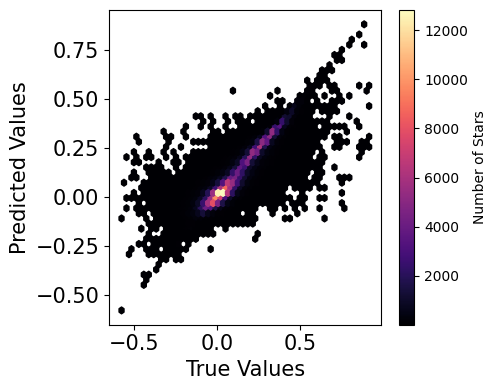

In [122]:
fig, ax = plt.subplots(figsize=[5, 4])

hb = ax.hexbin(y_test_mgfe, y_pred_mgfe, gridsize=50, cmap='magma', mincnt=1)

ax.set_xlabel("True Values", fontsize=15)
ax.set_ylabel("Predicted Values", fontsize=15)
ax.tick_params(labelsize=15)
cb = plt.colorbar(hb, ax=ax, label='Number of Stars')
fig.tight_layout()
plt.savefig('mgfe')
plt.show()

# make density plot to show correlation instead of using a bunch of points!!!

In [57]:
columns = balanced_data_flagless.drop(columns=['mg_fe']).columns.tolist()
columns = np.array(columns)
Importance = rlf.feature_importances_


print(np.around(Importance,1),columns)
columns_2_use = np.array(columns)

columns = columns[np.argsort(Importance)[::-1]]
Importance = Importance[np.argsort(Importance)[::-1]]
for i in range(len(Importance)):
    if round(Importance[i],2)>0:
        print(columns[i],round(Importance[i],3))

[0.  0.  0.6 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0. ] ['teff' 'logg' 'fe_h' 'vmic' 'vsini' 'mass' 'age' 'lbol' 'c_fe' 'n_fe'
 'o_fe' 'na_fe' 'al_fe' 'k_fe' 'si_fe' 'ca_fe' 'ti_fe' 'sc_fe' 'cr_fe'
 'mn_fe' 'co_fe' 'ni_fe' 'cu_fe' 'zn_fe' 'y_fe' 'ALi']
fe_h 0.636
si_fe 0.041
ca_fe 0.038
teff 0.029
mass 0.022
al_fe 0.022
mn_fe 0.021
lbol 0.02
vmic 0.016
o_fe 0.016
ti_fe 0.013
cr_fe 0.012
c_fe 0.012
zn_fe 0.012
cu_fe 0.011
logg 0.011
na_fe 0.01
sc_fe 0.01
co_fe 0.009
k_fe 0.009
age 0.009
n_fe 0.007
ni_fe 0.007
vsini 0.006


In [ ]:
fig, ax, = plt.subplots(figsize=[5,4])

ax.scatter(data_toomre['fe_h'], data_toomre['mg_fe'], s=0.2, alpha=0.3, c='black'=
ax.set_xlabel('[Fe/H]', fontsize=14)
ax.set_ylabel('[Mg/Fe]', fontsize=14)
ax.tickparams(labelsize=14)
fig.tight_layout()
plt.savefig(''

# RELOJ QUÍMICO

- Ver si solo utilizando las abundancias podamos calcular la edad de las estrellas.
- Propósito reloj químico: estimar edades de estrellas es muy dificil. Ya que una estrella de MS de baja masa evoluciona super poco. Predecir esa edad utilizando estos métodos es super bueno. Por esto las personas están usando métodos alternativos para estimar las edades.
- Tener cuidado con el overfitting. Cuando el modelo es muy complejo para la física que tienes en el momento.
- Qué podría causar que le precisión no cambie con el max_depth: otros parámetros.
- Cómo hacer balanceo de clases: repetir la clase categórica menor hasta que sea igual que la mayor
- Usar MS turn-off age. Restringimos por temperatua efectiva. Busca el paper que contiene esto.

In [59]:
hayden_criteria = (balanced_data_flagless_drop['teff'] < 6200) & (balanced_data_flagless_drop['fe_h'] < -1.0) & (balanced_data_flagless_drop['fe_h'] < 0.5)
clock_data = balanced_data_flagless_drop[hayden_criteria].drop(columns=['teff', 'logg', 'vmic', 'vsini', 'mass', 'lbol'])

In [126]:
len(clock_data), clock_data.columns
# plot: y, cr, mg, ba, si , na, mn, K, ca, o, ti, sc

(42460,
 Index(['fe_h', 'age', 'c_fe', 'n_fe', 'o_fe', 'na_fe', 'al_fe', 'k_fe',
        'mg_fe', 'si_fe', 'ca_fe', 'ti_fe', 'sc_fe', 'cr_fe', 'mn_fe', 'co_fe',
        'ni_fe', 'cu_fe', 'zn_fe', 'y_fe', 'ALi'],
       dtype='object'))

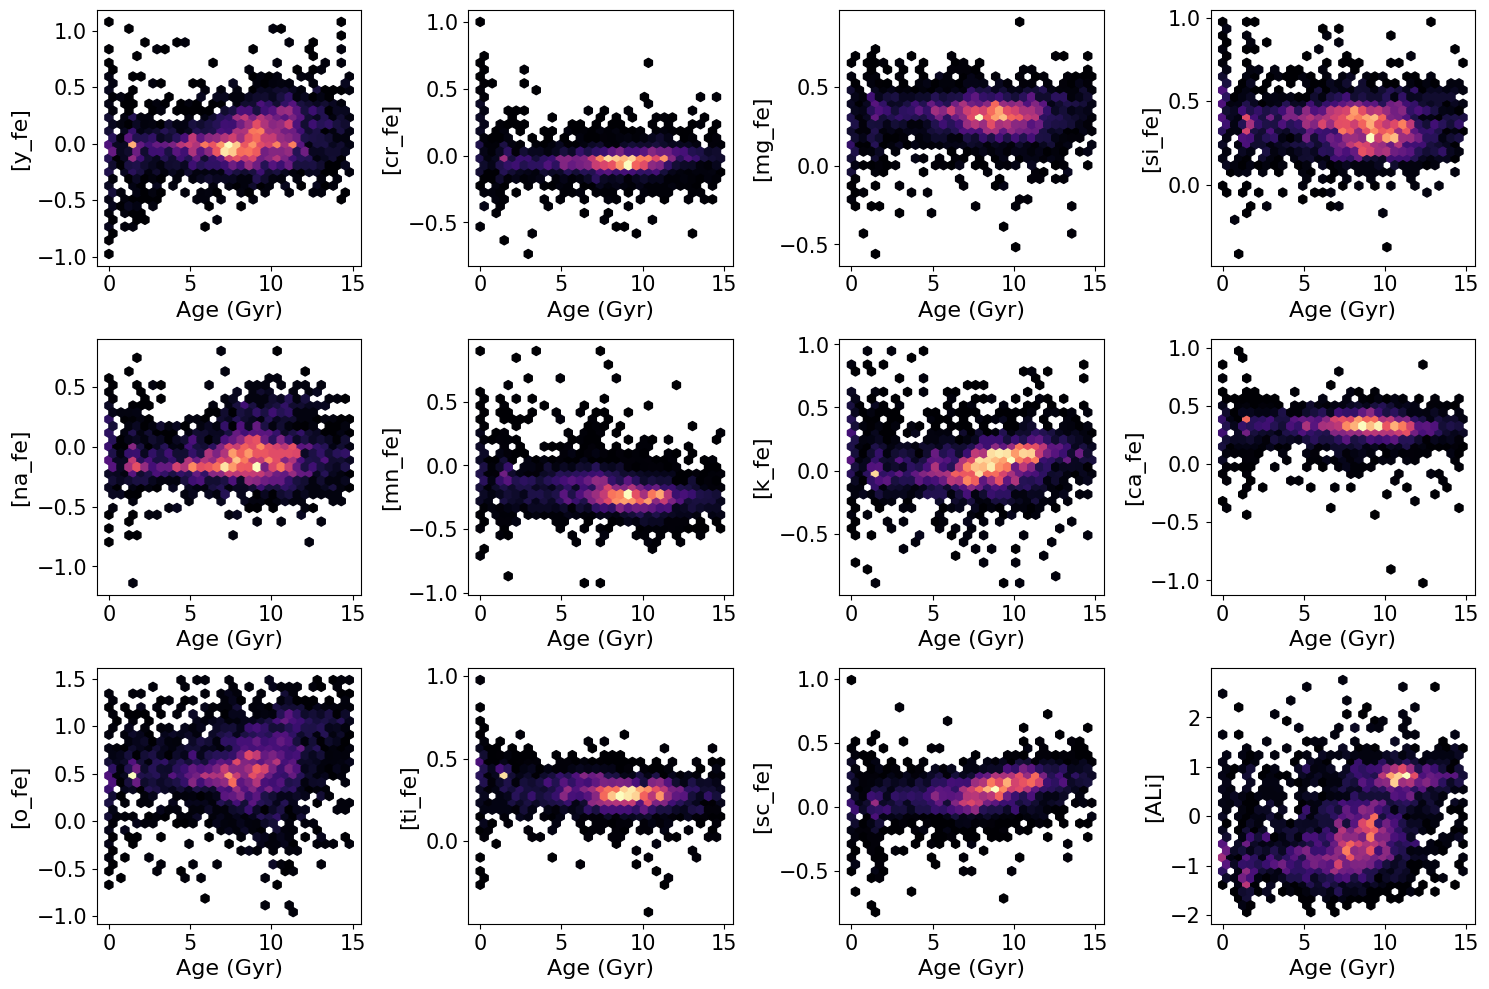

In [137]:
el = ['y_fe', 'cr_fe', 'mg_fe', 'si_fe', 'na_fe', 'mn_fe', 'k_fe', 'ca_fe', 'o_fe', 'ti_fe', 'sc_fe', 'ALi']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))

# Add common labels
plt.subplots_adjust(wspace=0.2, hspace=0.2)

vmin = 1  # Set this to a specific value if you want consistent scaling
vmax = len(data_toomre_flagless)  # Set this to a specific value if you want consistent scaling

# Use dummy ScalarMappable for the shared colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])

# Iterate through the list l to plot
for col, ax in zip(el, axes.flat):  # Use zip to pair l with flattened axes
    hb = ax.hexbin(clock_data['age'], 
            clock_data[col], 
            cmap='magma', gridsize=30, mincnt=1)
    ax.set_ylabel(f'[{col}]', fontsize=16)
    ax.set_xlabel('Age (Gyr)', fontsize=16)
    ax.tick_params(labelsize=15)

#cbar = fig.colorbar(hb, ax=axes, orientation='vertical', fraction=0.02, pad=0.1)
# Display the plot

fig.tight_layout()
plt.savefig('element_age')
plt.show()

In [60]:
X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(clock_data.drop(columns=['age']), clock_data['age'], test_size=0.5, random_state=np.random.randint(0,2e8)) # 50% training and 50% test
len(X_train_age),len(y_train_age),len(X_test_age),len(y_test_age)

(21230, 21230, 21230, 21230)

In [61]:
rlf = RandomForestRegressor(n_estimators=200,criterion='squared_error',
                             max_depth=19,
                             min_samples_split=4,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
rlf = rlf.fit(X_train_age, y_train_age)

#Predict the response for test dataset
y_pred_age = rlf.predict(X_test_age)
mae = mean_absolute_error(y_test_age, y_pred_age)
mse = mean_squared_error(y_test_age, y_pred_age)
r2 = r2_score(y_test_age, y_pred_age)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 0.1946114322299206
Mean Squared Error (MSE): 0.38186288775201144
R² Score: 0.9652191224911909


1 0.18975633196971775
2 0.3249597732228845
3 0.39584742500460446
4 0.4665012866703536
5 0.5395178410732369
6 0.6041176515756576
7 0.6662326095191844
8 0.7241074962708638
9 0.7807017175145388
10 0.8162952935003126
11 0.8583613302747095
12 0.8856008406913614
13 0.8965199677243473
14 0.9257906229519871
15 0.9335489854844118
16 0.9491248835577473
17 0.9539850315168857
18 0.9572732415428798
19 0.9629778222526341


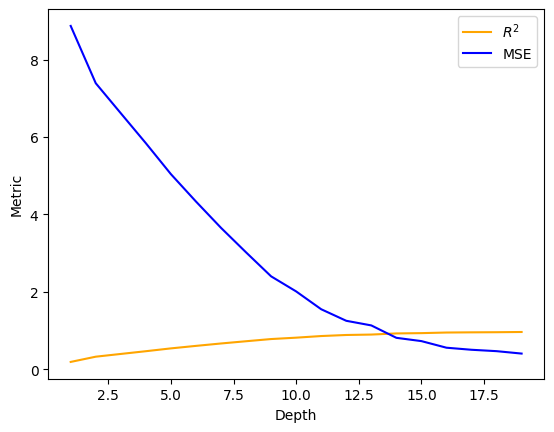

In [140]:
R2s = []
MSEs = []
depths = []

for m in np.arange(1,20,1):
    
    # Create Decision Tree classifer object
    clf = RandomForestRegressor(n_estimators=20, criterion='squared_error',
                                 max_depth=m,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 ccp_alpha=0)
    # Train Decision Tree Classifer
    with parallel_backend('threading', n_jobs=3):
        clf = clf.fit(X_train_age,y_train_age)
    
    #Predict the response for test dataset
    y_pred_age = clf.predict(X_test_age)
    mse = mean_squared_error(y_test_age, y_pred_age)
    r2 = r2_score(y_test_age, y_pred_age)
    print(m,r2)
    MSEs.append(mse)
    R2s.append(r2)
    depths.append(m)
plt.plot(depths,R2s, c='orange', label='$R^2$')
plt.plot(depths, MSEs, c='blue', label='MSE')
plt.xlabel('Depth')
plt.ylabel('Metric')
plt.legend()
plt.show()

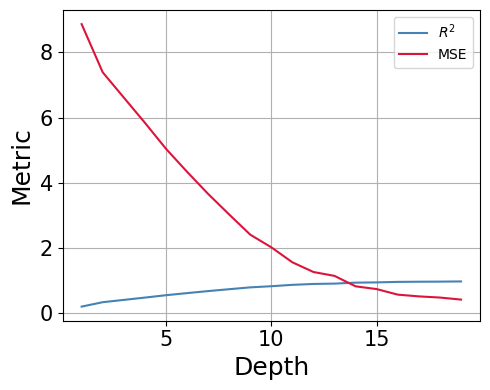

In [145]:
fig, ax = plt.subplots(figsize=[5, 4])

ax.plot(depths,R2s, c='steelblue', label='$R^2$')
ax.plot(depths, MSEs, c='crimson', label='MSE')
ax.set_xlabel('Depth', fontsize=18)
ax.set_ylabel('Metric', fontsize=18)
ax.tick_params(labelsize=15)
ax.grid()
fig.tight_layout()
plt.legend()
plt.savefig('metrics_reloj.png')
plt.show()

In [142]:
rlf = RandomForestRegressor(n_estimators=200,criterion='squared_error',
                             max_depth=18,
                             min_samples_split=4,
                             min_samples_leaf=1,
                             ccp_alpha=0)
# Train Decision Tree Classifer
rlf = rlf.fit(X_train_age, y_train_age)

#Predict the response for test dataset
y_pred_age = rlf.predict(X_test_age)
mae = mean_absolute_error(y_test_age, y_pred_age)
mse = mean_squared_error(y_test_age, y_pred_age)
r2 = r2_score(y_test_age, y_pred_age)
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 0.24845773337370047
Mean Squared Error (MSE): 0.43333322523144335
R² Score: 0.9604166126800253


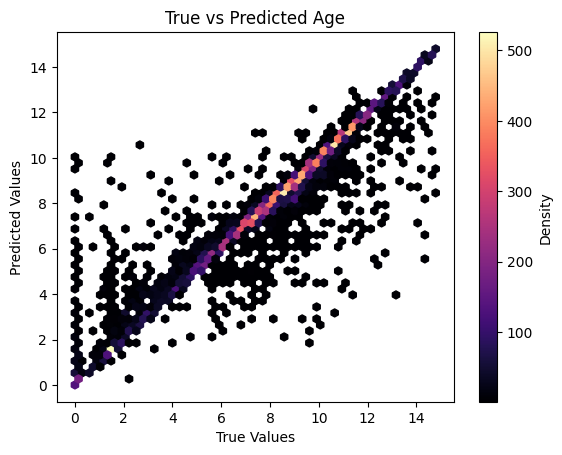

In [143]:
fig, ax = plt.subplots(figsize=[5, 4])

hb = ax.hexbin(y_test_age, y_pred_age, gridsize=50, cmap='magma', mincnt=1)
plt.colorbar(label='Density')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Age")
plt.show()
# make density plot to show correlation instead of using a bunch of points!!!

In [144]:
columns = clock_data.drop(columns=['age']).columns.tolist()
columns = np.array(columns)
Importance = rlf.feature_importances_


print(np.around(Importance,1),columns)
columns_2_use = np.array(columns)

columns = columns[np.argsort(Importance)[::-1]]
Importance = Importance[np.argsort(Importance)[::-1]]
for i in range(len(Importance)):
    if round(Importance[i],1)>0:
        print(columns[i],round(Importance[i],3))

[0.1 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.1 0.  0.  0.  0.  0.1 0.
 0.  0.2] ['fe_h' 'c_fe' 'n_fe' 'o_fe' 'na_fe' 'al_fe' 'k_fe' 'mg_fe' 'si_fe'
 'ca_fe' 'ti_fe' 'sc_fe' 'cr_fe' 'mn_fe' 'co_fe' 'ni_fe' 'cu_fe' 'zn_fe'
 'y_fe' 'ALi']
ALi 0.207
ti_fe 0.154
sc_fe 0.072
cu_fe 0.056
fe_h 0.054
